# Multi-frequency DEC visitation modeling

This notebook trains and tests separate forecasting models for hourly, daily, monthly, and yearly visitation. It follows the State_model convention of chronological evaluation: later observations are held out, never randomly mixed into training.

Models compared:
- previous-period baseline;
- seasonal baseline (24 hours, 7 days, 12 months, or 1 year);
- regularized ridge regression on calendar, location, lag, and rolling-history features.

Lag features use the previous observed value, so results represent one-step-ahead forecasting. The notebook uses only NumPy, Pandas, and Matplotlib.

In [14]:
from pathlib import Path
import json, warnings, sys
import numpy as np
import pandas as pd
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'final code' else NOTEBOOK_DIR
# Load compiled ML packages only from the folder matching this notebook kernel's Python ABI.
# Python 3.11 and 3.12 wheels are not interchangeable.
package_candidates = {
    (3,11): PROJECT_ROOT / 'final code' / '.ml_packages_py311',
    (3,12): PROJECT_ROOT / 'final code' / '.ml_packages',
}
LOCAL_ML_PACKAGES = package_candidates.get(sys.version_info[:2])
sys.path[:] = [p for p in sys.path if '.ml_packages' not in str(p)]
if LOCAL_ML_PACKAGES and LOCAL_ML_PACKAGES.exists():
    sys.path.insert(0,str(LOCAL_ML_PACKAGES))
for module_name in [name for name in list(sys.modules) if name=='sklearn' or name.startswith('sklearn.')]:
    del sys.modules[module_name]
print('Python kernel:',sys.version.split()[0])
print('ML package folder:',LOCAL_ML_PACKAGES)
try:
    import matplotlib
    matplotlib.use('Agg')
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ImportError:
    plt = None
    HAS_MATPLOTLIB = False

warnings.filterwarnings('ignore')
DATA_DIR = PROJECT_ROOT / 'data'
OUTPUT_DIR = DATA_DIR / 'ml_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42

CONFIG = {
    'hourly': {'file':'hourly.csv','lags':[1,24,168],'rolls':[24,168],'seasonal_lag':24,'min_rows':500},
    'daily': {'file':'daily.csv','lags':[1,7,28],'rolls':[7,28],'seasonal_lag':7,'min_rows':90},
    'monthly': {'file':'monthly.csv','lags':[1,3,12],'rolls':[3,12],'seasonal_lag':12,'min_rows':24},
    'yearly': {'file':'yearly.csv','lags':[1,2,3],'rolls':[2,3],'seasonal_lag':1,'min_rows':6},
}
print('Input folder:',DATA_DIR)
print('Output folder:',OUTPUT_DIR)

Python kernel: 3.11.11
ML package folder: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/Final_CSC_Workspace/final code/.ml_packages_py311
Input folder: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/Final_CSC_Workspace/data
Output folder: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/Final_CSC_Workspace/data/ml_outputs


In [15]:
def load_frequency(name):
    path = DATA_DIR / CONFIG[name]['file']
    df = pd.read_csv(path)
    df['start_date'] = pd.to_datetime(df.start_date,errors='coerce')
    df['visitation_count'] = pd.to_numeric(df.visitation_count,errors='coerce')
    df = df.dropna(subset=['location','start_date','visitation_count']).query('visitation_count >= 0').copy()
    return df.sort_values(['location','start_date']).reset_index(drop=True)

profiles = []
for name in CONFIG:
    df = load_frequency(name)
    profiles.append({'frequency':name,'records':len(df),'locations':df.location.nunique(),'start':df.start_date.min(),'end':df.start_date.max(),'mean_visitation':df.visitation_count.mean()})
profile_df = pd.DataFrame(profiles)
display(profile_df)

,frequency,records,locations,start,end,mean_visitation
0,hourly,49033,1,2020-07-22 12:00:00,2026-04-01 13:00:00,2.981359
1,daily,2051,1,2020-07-22 00:00:00,2026-04-01 00:00:00,71.274988
2,monthly,21240,102,1991-01-01 00:00:00,2026-07-01 00:00:00,130.704180
3,yearly,2148,102,1991-01-01 00:00:00,2026-01-01 00:00:00,1353.700087


## DEC–AllTrails location and geometry enrichment

This section links DEC location names to the revised AllTrails crosswalk and downloaded trail geometries before modeling. A representative trail coordinate is derived from each downloaded path. Locations without a downloaded geometry are retained in a manual-coordinate template; existing manual entries are never overwritten. The compact outputs can later supply trail geometry to the DEC app and coordinates to a weather-data workflow.

In [ ]:
import re
from difflib import SequenceMatcher

ALLTRAILS_CROSSWALK_FILE = PROJECT_ROOT / 'DEC_AllTrails_location_crosswalk_revised.xlsx'
ALLTRAILS_MAP_DIR = PROJECT_ROOT / 'AllTrails_map_downloads'
MANUAL_COORDINATE_FILE = DATA_DIR / 'manual_trail_coordinates.csv'
LOCATION_ENRICHMENT_FILE = OUTPUT_DIR / 'alltrails_location_enrichment.csv'
GEOMETRY_CATALOG_FILE = OUTPUT_DIR / 'alltrails_geometry_catalog.csv'
UNMATCHED_LOCATION_FILE = OUTPUT_DIR / 'alltrails_locations_needing_coordinates.csv'
WEATHER_FEATURE_FILE = DATA_DIR / 'trail_weather_features.csv'

def normalized_trail_key(value):
    return re.sub(r'[^a-z0-9]+','',str(value).lower())

def url_trail_slug(value):
    match=re.search(r'alltrails\.com/(?:explore/)?trail/[^/]+/[^/]+/([a-z0-9-]+)',str(value).lower())
    return match.group(1) if match else ''

def geometry_points(geometry):
    coordinates=geometry.get('coordinates',[])
    if geometry.get('type')=='LineString': return coordinates
    if geometry.get('type')=='MultiLineString': return [point for line in coordinates for point in line]
    return []

def read_alltrails_geometry(path):
    payload=json.loads(path.read_text(encoding='utf-8'))
    features=payload.get('features',[])
    points=[point for feature in features for point in geometry_points(feature.get('geometry',{})) if len(point)>=2]
    if not points: raise ValueError(f'No line coordinates found in {path.name}')
    longitude=np.asarray([point[0] for point in points],float); latitude=np.asarray([point[1] for point in points],float)
    elevations=np.asarray([point[2] for point in points if len(point)>2 and point[2] is not None],float)
    names=[feature.get('properties',{}).get('name') for feature in features if geometry_points(feature.get('geometry',{})) and feature.get('properties',{}).get('name')]
    return {'geometry_file':path.name,'alltrails_trail_name':names[0] if names else path.stem.replace('_',' '),'geometry_key':normalized_trail_key(path.stem),'geometry_point_count':len(points),'geometry_latitude':float(np.median(latitude)),'geometry_longitude':float(np.median(longitude)),'geometry_min_latitude':float(latitude.min()),'geometry_max_latitude':float(latitude.max()),'geometry_min_longitude':float(longitude.min()),'geometry_max_longitude':float(longitude.max()),'geometry_mean_elevation':float(elevations.mean()) if len(elevations) else np.nan}

if not ALLTRAILS_CROSSWALK_FILE.exists(): raise FileNotFoundError(ALLTRAILS_CROSSWALK_FILE)
if not ALLTRAILS_MAP_DIR.exists(): raise FileNotFoundError(ALLTRAILS_MAP_DIR)
crosswalk=pd.read_excel(ALLTRAILS_CROSSWALK_FILE,sheet_name='AllTrails Crosswalk',header=3).dropna(subset=['Location']).copy()
crosswalk=crosswalk.rename(columns={'Location':'location','Most likely AllTrails URL':'alltrails_url','Other candidate AllTrails URLs':'other_alltrails_urls','Confidence':'crosswalk_confidence','Included in app?':'included_in_app','Human notes':'crosswalk_human_notes','Computer Match notes':'crosswalk_computer_notes'})
crosswalk['location']=crosswalk.location.astype(str).str.strip(); crosswalk['url_slug']=crosswalk.alltrails_url.map(url_trail_slug); crosswalk['url_key']=crosswalk.url_slug.map(normalized_trail_key)
geometry_catalog=pd.DataFrame([read_alltrails_geometry(path) for path in sorted(ALLTRAILS_MAP_DIR.glob('*.js'))])
geometry_catalog.to_csv(GEOMETRY_CATALOG_FILE,index=False)

def best_geometry_match(row):
    if not row.url_key: return pd.Series({'geometry_file':np.nan,'geometry_match_score':np.nan,'geometry_match_method':'no_valid_crosswalk_url'})
    scores=geometry_catalog.geometry_key.map(lambda key: SequenceMatcher(None,row.url_key,key).ratio())
    best_index=scores.idxmax(); score=float(scores.loc[best_index])
    exact=geometry_catalog.loc[best_index,'geometry_key']==row.url_key
    if not exact and score<0.72: return pd.Series({'geometry_file':np.nan,'geometry_match_score':score,'geometry_match_method':'crosswalk_only_no_download'})
    return pd.Series({'geometry_file':geometry_catalog.loc[best_index,'geometry_file'],'geometry_match_score':score,'geometry_match_method':'exact_url_slug' if exact else 'fuzzy_url_slug'})

crosswalk=pd.concat([crosswalk,crosswalk.apply(best_geometry_match,axis=1)],axis=1)
dec_locations=sorted(set().union(*[set(pd.read_csv(DATA_DIR/cfg['file'],usecols=['location']).location.dropna().astype(str).str.strip()) for cfg in CONFIG.values()]))
location_enrichment=pd.DataFrame({'location':dec_locations}).merge(crosswalk,on='location',how='left').merge(geometry_catalog.drop(columns=['geometry_key']),on='geometry_file',how='left')
manual_columns=['location','manual_latitude','manual_longitude','manual_location_notes']
if MANUAL_COORDINATE_FILE.exists():
    manual=pd.read_csv(MANUAL_COORDINATE_FILE)
    for column in manual_columns:
        if column not in manual: manual[column]=np.nan
    manual=manual[manual_columns].drop_duplicates('location',keep='last')
else:
    manual=pd.DataFrame(columns=manual_columns)
needed=pd.DataFrame({'location':location_enrichment.loc[location_enrichment.geometry_latitude.isna(),'location']})
manual=pd.concat([manual,needed[~needed.location.isin(manual.location)]],ignore_index=True)
manual=manual.reindex(columns=manual_columns).sort_values('location').reset_index(drop=True); manual.to_csv(MANUAL_COORDINATE_FILE,index=False)
location_enrichment=location_enrichment.merge(manual,on='location',how='left')
location_enrichment['model_latitude']=location_enrichment.geometry_latitude.combine_first(pd.to_numeric(location_enrichment.manual_latitude,errors='coerce'))
location_enrichment['model_longitude']=location_enrichment.geometry_longitude.combine_first(pd.to_numeric(location_enrichment.manual_longitude,errors='coerce'))
location_enrichment['coordinate_source']=np.select([location_enrichment.geometry_latitude.notna(),location_enrichment.model_latitude.notna()],['AllTrails downloaded geometry','Manual coordinates'],default='Needs coordinates')
location_enrichment.to_csv(LOCATION_ENRICHMENT_FILE,index=False)
location_enrichment[location_enrichment.model_latitude.isna()].to_csv(UNMATCHED_LOCATION_FILE,index=False)
LOCATION_FEATURES=['model_latitude','model_longitude','geometry_mean_elevation']
location_model_features=location_enrichment[['location']+LOCATION_FEATURES].copy()
print(f'Matched {location_enrichment.geometry_file.notna().sum():,} of {len(location_enrichment):,} DEC locations to {len(geometry_catalog):,} downloaded AllTrails geometries.')
print(f'{location_enrichment.model_latitude.notna().sum():,} locations currently have modeling/weather coordinates; {location_enrichment.model_latitude.isna().sum():,} need manual coordinates.')
print('Add missing latitude/longitude values here without changing this notebook:',MANUAL_COORDINATE_FILE)
print('Optional future weather input:',WEATHER_FEATURE_FILE,'with location, start_date, and numeric weather_* columns (for example weather_temp_mean_c and weather_rain_mm).')
display(location_enrichment.groupby('coordinate_source',dropna=False).size().rename('locations').reset_index())
display(location_enrichment[['location','alltrails_trail_name','geometry_file','geometry_match_method','geometry_match_score','model_latitude','model_longitude','coordinate_source']])

In [16]:
def add_features(df,name):
    cfg = CONFIG[name]
    out = df.sort_values(['location','start_date']).copy()
    grouped = out.groupby('location',group_keys=False)['visitation_count']
    for lag in cfg['lags']:
        out[f'lag_{lag}'] = grouped.shift(lag)
    for window in cfg['rolls']:
        out[f'rolling_mean_{window}'] = grouped.transform(lambda s: s.shift(1).rolling(window,min_periods=max(2,window//3)).mean())
    out['year_centered'] = out.start_date.dt.year - out.start_date.dt.year.min()
    out['month_sin'] = np.sin(2*np.pi*out.start_date.dt.month/12)
    out['month_cos'] = np.cos(2*np.pi*out.start_date.dt.month/12)
    out['dow_sin'] = np.sin(2*np.pi*out.start_date.dt.dayofweek/7)
    out['dow_cos'] = np.cos(2*np.pi*out.start_date.dt.dayofweek/7)
    out['hour_sin'] = np.sin(2*np.pi*out.start_date.dt.hour/24)
    out['hour_cos'] = np.cos(2*np.pi*out.start_date.dt.hour/24)
    out['time_index'] = out.groupby('location').cumcount()
    feature_cols = ['year_centered','month_sin','month_cos','dow_sin','dow_cos','hour_sin','hour_cos','time_index'] + [f'lag_{x}' for x in cfg['lags']] + [f'rolling_mean_{x}' for x in cfg['rolls']]
    out = out.dropna(subset=feature_cols+['visitation_count']).copy()
    eligible = out.groupby('location').size()
    eligible = eligible[eligible >= cfg['min_rows']].index
    out = out[out.location.isin(eligible)].copy()
    return out, feature_cols

def chronological_split(df,test_fraction=0.20):
    parts=[]
    for location,g in df.groupby('location',sort=False):
        g=g.sort_values('start_date').copy()
        n_test=max(1,int(np.ceil(len(g)*test_fraction)))
        g['split']='train'; g.iloc[-n_test:,g.columns.get_loc('split')]='test'
        parts.append(g)
    return pd.concat(parts).sort_values(['location','start_date']).reset_index(drop=True)

def design_matrix(frame,feature_cols,train_mask):
    numeric=frame[feature_cols].astype(float).copy()
    means=numeric.loc[train_mask].mean(); stds=numeric.loc[train_mask].std().replace(0,1).fillna(1)
    numeric=(numeric-means)/stds
    locations=pd.get_dummies(frame.location,prefix='location',dtype=float)
    X=np.column_stack([np.ones(len(frame)),numeric.to_numpy(),locations.to_numpy()])
    names=['intercept']+feature_cols+locations.columns.tolist()
    return X,names

def ridge_fit(X,y,alpha):
    penalty=np.eye(X.shape[1])*alpha; penalty[0,0]=0
    return np.linalg.solve(X.T@X+penalty,X.T@y)

def metrics(y,p):
    y=np.asarray(y,float); p=np.asarray(p,float); mask=np.isfinite(y)&np.isfinite(p); y,p=y[mask],p[mask]
    if not len(y): return {'n':0,'MAE':np.nan,'RMSE':np.nan,'R2':np.nan,'sMAPE_pct':np.nan,'bias':np.nan}
    mae=np.mean(np.abs(y-p)); rmse=np.sqrt(np.mean((y-p)**2)); denom=np.sum((y-y.mean())**2)
    r2=1-np.sum((y-p)**2)/denom if denom>0 else np.nan
    smape=100*np.mean(2*np.abs(p-y)/(np.abs(y)+np.abs(p)+1e-9))
    return {'n':len(y),'MAE':mae,'RMSE':rmse,'R2':r2,'sMAPE_pct':smape,'bias':np.mean(p-y)}

In [17]:
def run_frequency_model(name):
    raw=load_frequency(name)
    model_data,feature_cols=add_features(raw,name)
    if model_data.empty: raise ValueError(f'No eligible rows for {name}')
    model_data=chronological_split(model_data)
    train_mask=model_data.split.eq('train').to_numpy(); test_mask=~train_mask
    X,feature_names=design_matrix(model_data,feature_cols,train_mask)
    y=np.log1p(model_data.visitation_count.to_numpy(float))

    # Tune alpha using only the final 20% of each training location as validation.
    validation=np.zeros(len(model_data),dtype=bool)
    for location,idx in model_data[model_data.split.eq('train')].groupby('location').groups.items():
        ordered=np.array(list(idx)); n=max(1,int(np.ceil(len(ordered)*0.20))); validation[ordered[-n:]]=True
    subtrain=train_mask & ~validation
    alpha_scores=[]
    for alpha in [0.1,1.0,10.0,100.0,1000.0]:
        coef=ridge_fit(X[subtrain],y[subtrain],alpha)
        pred=np.maximum(0,np.expm1(X[validation]@coef))
        alpha_scores.append((alpha,metrics(model_data.loc[validation,'visitation_count'],pred)['RMSE']))
    best_alpha=min(alpha_scores,key=lambda x:x[1])[0]
    coef=ridge_fit(X[train_mask],y[train_mask],best_alpha)
    ridge_pred=np.maximum(0,np.expm1(X[test_mask]@coef))

    test=model_data.loc[test_mask].copy()
    test['observed']=test.visitation_count
    test['ridge_prediction']=ridge_pred
    test['previous_prediction']=test['lag_1']
    test['seasonal_prediction']=test[f"lag_{CONFIG[name]['seasonal_lag']}"]
    result_rows=[]
    for model,col in [('Previous observation','previous_prediction'),('Seasonal naive','seasonal_prediction'),('Ridge calendar + history','ridge_prediction')]:
        result_rows.append({'frequency':name,'model':model,'best_alpha':best_alpha if model.startswith('Ridge') else np.nan,'train_rows':int(train_mask.sum()),'test_rows':int(test_mask.sum()),'eligible_locations':model_data.location.nunique(),**metrics(test.observed,test[col])})
    results=pd.DataFrame(result_rows)
    keep=['location','start_date','observed','previous_prediction','seasonal_prediction','ridge_prediction','split']
    test[keep].to_csv(OUTPUT_DIR/f'{name}_test_predictions.csv',index=False)

    # Plot the eligible location with the most held-out observations.
    plot_location=test.location.value_counts().index[0]
    plot_df=test[test.location.eq(plot_location)].sort_values('start_date').tail(500)
    if HAS_MATPLOTLIB:
        fig,ax=plt.subplots(figsize=(13,5))
        ax.plot(plot_df.start_date,plot_df.observed,label='Observed',linewidth=1.8)
        ax.plot(plot_df.start_date,plot_df.ridge_prediction,label='Ridge prediction',linewidth=1.3)
        ax.set_title(f'{name.title()} held-out forecast: {plot_location}')
        ax.set_ylabel('Visitation count'); ax.legend(); ax.grid(alpha=.25); fig.tight_layout()
        fig.savefig(OUTPUT_DIR/f'{name}_observed_vs_predicted.png',dpi=160,bbox_inches='tight'); plt.close(fig)
    return results,test,best_alpha,alpha_scores

all_results=[]; prediction_tables={}
for frequency in CONFIG:
    print(f'\nTraining {frequency} model...')
    results,predictions,best_alpha,alpha_scores=run_frequency_model(frequency)
    all_results.append(results); prediction_tables[frequency]=predictions
    print('Alpha validation RMSE:',alpha_scores)
    display(results)
results_df=pd.concat(all_results,ignore_index=True)
results_df.to_csv(OUTPUT_DIR/'multi_frequency_model_results.csv',index=False)


Training hourly model...
Alpha validation RMSE: [(0.1, 5.288463068689551), (1.0, 5.2881123909297205), (10.0, 5.284613625540991), (100.0, 5.2503635666758575), (1000.0, 4.963155350868462)]


,frequency,model,best_alpha,train_rows,test_rows,eligible_locations,n,MAE,RMSE,R2,sMAPE_pct,bias
0,hourly,Previous observation,NaN,39092,9773,1,9773,1.490433,3.536192,0.454308,51.200522,0.000000
1,hourly,Seasonal naive,NaN,39092,9773,1,9773,2.026604,4.859933,-0.030710,60.166441,0.000205
2,hourly,Ridge calendar + history,1000.0,39092,9773,1,9773,1.461680,6.148862,-0.649929,107.674636,-0.481009



Training daily model...
Alpha validation RMSE: [(0.1, 44.56742524633038), (1.0, 44.58809245092156), (10.0, 44.70397734779604), (100.0, 45.06459409949812), (1000.0, 48.24945314454622)]


,frequency,model,best_alpha,train_rows,test_rows,eligible_locations,n,MAE,RMSE,R2,sMAPE_pct,bias
0,daily,Previous observation,NaN,1618,405,1,405,33.059259,51.559938,0.052488,80.593933,0.046914
1,daily,Seasonal naive,NaN,1618,405,1,405,28.750617,42.732357,0.349161,78.940045,-0.217284
2,daily,Ridge calendar + history,0.1,1618,405,1,405,22.499743,36.155625,0.534079,61.469385,-11.478597



Training monthly model...
Alpha validation RMSE: [(0.1, 1932.316896697053), (1.0, 2099.6972245522034), (10.0, 3519.9076890969527), (100.0, 14633.400663972217), (1000.0, 98929.4770516287)]


,frequency,model,best_alpha,train_rows,test_rows,eligible_locations,n,MAE,RMSE,R2,sMAPE_pct,bias
0,monthly,Previous observation,NaN,15968,4031,83,4031,66.753898,158.343359,0.668444,50.384217,0.906101
1,monthly,Seasonal naive,NaN,15968,4031,83,4031,63.061945,151.340165,0.697123,47.095507,6.622763
2,monthly,Ridge calendar + history,0.1,15968,4031,83,4031,150.846434,1216.961357,-18.584439,49.818121,90.047183



Training yearly model...
Alpha validation RMSE: [(0.1, 3034.546117402696), (1.0, 5004.560795655804), (10.0, 14348.07469830813), (100.0, 34273.160983571834), (1000.0, 10315.93276352549)]


,frequency,model,best_alpha,train_rows,test_rows,eligible_locations,n,MAE,RMSE,R2,sMAPE_pct,bias
0,yearly,Previous observation,NaN,1441,396,93,396,621.263731,1314.461009,0.625475,47.946208,274.082817
1,yearly,Seasonal naive,NaN,1441,396,93,396,621.263731,1314.461009,0.625475,47.946208,274.082817
2,yearly,Ridge calendar + history,0.1,1441,396,93,396,1827.542002,8525.022171,-14.753490,49.826861,1521.121888


In [18]:
best_models=(results_df.sort_values(['frequency','RMSE']).groupby('frequency',as_index=False).first())
print('Best held-out model by frequency:')
display(best_models[['frequency','model','n','MAE','RMSE','R2','sMAPE_pct','bias']])

coverage=[]
for frequency,pred in prediction_tables.items():
    coverage.append({'frequency':frequency,'test_rows':len(pred),'test_locations':pred.location.nunique(),'test_start':pred.start_date.min(),'test_end':pred.start_date.max()})
coverage_df=pd.DataFrame(coverage)
coverage_df.to_csv(OUTPUT_DIR/'test_coverage_summary.csv',index=False)
display(coverage_df)
print('Saved outputs:')
for path in sorted(OUTPUT_DIR.iterdir()): print('-',path.name)

Best held-out model by frequency:


,frequency,model,n,MAE,RMSE,R2,sMAPE_pct,bias
0,daily,Ridge calendar + history,405,22.499743,36.155625,0.534079,61.469385,-11.478597
1,hourly,Previous observation,9773,1.490433,3.536192,0.454308,51.200522,0.000000
2,monthly,Seasonal naive,4031,63.061945,151.340165,0.697123,47.095507,6.622763
3,yearly,Previous observation,396,621.263731,1314.461009,0.625475,47.946208,274.082817


,frequency,test_rows,test_locations,test_start,test_end
0,hourly,9773,1,2025-02-11 19:00:00,2026-04-01 13:00:00
1,daily,405,1,2025-02-17 00:00:00,2026-04-01 00:00:00
2,monthly,4031,83,2015-06-01 00:00:00,2026-07-01 00:00:00
3,yearly,396,93,2015-01-01 00:00:00,2026-01-01 00:00:00


Saved outputs:
- daily_best_strava_model.png
- daily_observed_vs_predicted.png
- daily_test_predictions.csv
- elm_ridge_edge_model_predictions.csv
- elm_ridge_edge_model_results.csv
- elm_ridge_monthly_visitation_vs_estimate.png
- elm_ridge_relevant_edges_heatmap.png
- elm_ridge_relevant_strava_edges.csv
- elm_ridge_relevant_strava_edges.png
- hourly_best_strava_model.png
- hourly_observed_vs_predicted.png
- hourly_test_predictions.csv
- monthly_best_strava_model.png
- monthly_observed_vs_predicted.png
- monthly_test_predictions.csv
- multi_frequency_model_results.csv
- per_location_performance.csv
- strava_enhanced_model_results.csv
- strava_enhanced_test_predictions.csv
- strava_improvement_summary.csv
- strava_pca_coverage.csv
- test_coverage_summary.csv
- yearly_best_strava_model.png
- yearly_observed_vs_predicted.png
- yearly_test_predictions.csv


## Strava-enhanced models with training-only PCA

This section reuses the compact statewide edge matrix and network summary already derived from `State_model/monthly`; it does not recreate or copy the multi-gigabyte Strava files. The edge matrix contains the 1,000 high-coverage edges selected by the latest State_model workflow.

For every frequency, later observations remain held out. Imputation, scaling, and PCA are fitted only on training periods. The section compares Ridge, Random Forest, and histogram gradient boosting with and without Strava summary/PCA features.

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

STATE_MODEL_OUTPUTS = PROJECT_ROOT / 'State_model' / 'global_model_outputs'
EDGE_MATRIX_FILE = STATE_MODEL_OUTPUTS / 'statewide_edge_month_matrix.csv'
NETWORK_FEATURE_FILE = STATE_MODEL_OUTPUTS / 'statewide_monthly_network_features.csv'
if not EDGE_MATRIX_FILE.exists() or not NETWORK_FEATURE_FILE.exists():
    raise FileNotFoundError('Run the latest State_model global-model block first; its compact edge matrix and network summary are required.')

edge_monthly = pd.read_csv(EDGE_MATRIX_FILE)
network_monthly = pd.read_csv(NETWORK_FEATURE_FILE)
edge_monthly['start_date'] = pd.to_datetime(edge_monthly.start_date).dt.to_period('M').dt.to_timestamp()
network_monthly['start_date'] = pd.to_datetime(network_monthly.start_date).dt.to_period('M').dt.to_timestamp()
EDGE_COLUMNS = [c for c in edge_monthly.columns if c.startswith('edge_')]
NETWORK_COLUMNS = [c for c in network_monthly.columns if c.startswith('statewide_')]
print(f'Reusing {len(edge_monthly):,} monthly periods, {len(EDGE_COLUMNS):,} edge columns, and {len(NETWORK_COLUMNS):,} statewide summary features.')
print('No new Strava edge or monthly data files are created.')

def make_ohe():
    try: return OneHotEncoder(handle_unknown='ignore',sparse_output=False)
    except TypeError: return OneHotEncoder(handle_unknown='ignore',sparse=False)

def strava_period_tables(frequency):
    if frequency != 'yearly':
        edges=edge_monthly.copy(); summary=network_monthly.copy()
        edges['_strava_period']=edges.start_date; summary['_strava_period']=summary.start_date
    else:
        e=edge_monthly.copy(); e['_year']=e.start_date.dt.year
        edges=e.groupby('_year',as_index=False)[EDGE_COLUMNS].sum(); edges['_strava_period']=pd.to_datetime(edges._year.astype(str)+'-01-01')
        s=network_monthly.copy(); s['_year']=s.start_date.dt.year
        sum_cols=[c for c in NETWORK_COLUMNS if 'mean_' not in c and 'median_' not in c and '_q' not in c and '_std' not in c and 'reported_edges' not in c]
        mean_cols=[c for c in NETWORK_COLUMNS if c not in sum_cols]
        summary=pd.concat([s.groupby('_year')[sum_cols].sum(),s.groupby('_year')[mean_cols].mean()],axis=1).reset_index()
        summary['_strava_period']=pd.to_datetime(summary._year.astype(str)+'-01-01')
    return edges,summary

def attach_weather_features(frame,frequency):
    # Future weather input: one row per location/date with weather_* numeric columns.
    # Daily weather is repeated across hours and aggregated for monthly/yearly models.
    if not WEATHER_FEATURE_FILE.exists(): return frame,[]
    weather=pd.read_csv(WEATHER_FEATURE_FILE)
    required={'location','start_date'}
    if not required.issubset(weather.columns): raise ValueError(f'{WEATHER_FEATURE_FILE.name} must contain location and start_date columns')
    weather['start_date']=pd.to_datetime(weather.start_date,errors='coerce')
    weather_columns=[column for column in weather.columns if column.startswith('weather_')]
    if not weather_columns: return frame,[]
    for column in weather_columns: weather[column]=pd.to_numeric(weather[column],errors='coerce')
    period_code={'hourly':'D','daily':'D','monthly':'M','yearly':'Y'}[frequency]
    weather['_weather_period']=weather.start_date.dt.to_period(period_code).dt.start_time
    sum_columns=[column for column in weather_columns if any(word in column for word in ['precip','rain','snow'])]
    mean_columns=[column for column in weather_columns if column not in sum_columns]
    aggregations={**{column:'mean' for column in mean_columns},**{column:'sum' for column in sum_columns}}
    weather=weather.groupby(['location','_weather_period'],as_index=False).agg(aggregations)
    out=frame.copy(); out['_weather_period']=out.start_date.dt.to_period(period_code).dt.start_time
    return out.merge(weather,on=['location','_weather_period'],how='left'),weather_columns

def prepare_strava_model_data(frequency):
    raw=load_frequency(frequency)
    base,history_features=add_features(raw,frequency)
    base=base.merge(location_model_features,on='location',how='left')
    base,weather_features=attach_weather_features(base,frequency)
    base['_strava_period']=(base.start_date.dt.to_period('Y').dt.start_time if frequency=='yearly' else base.start_date.dt.to_period('M').dt.start_time)
    edges,summary=strava_period_tables(frequency)
    base=base.merge(summary[['_strava_period']+NETWORK_COLUMNS],on='_strava_period',how='inner')
    base=chronological_split(base)
    train_periods=base.loc[base.split.eq('train'),'_strava_period'].drop_duplicates()
    edge_train=edges[edges._strava_period.isin(train_periods)].copy()
    n_components=max(1,min(10,len(EDGE_COLUMNS),edge_train._strava_period.nunique()-1))
    edge_imputer=SimpleImputer(strategy='median'); edge_scaler=StandardScaler(); edge_pca=PCA(n_components=n_components,random_state=RANDOM_STATE)
    train_scaled=edge_scaler.fit_transform(edge_imputer.fit_transform(edge_train[EDGE_COLUMNS]))
    edge_pca.fit(train_scaled)
    all_scaled=edge_scaler.transform(edge_imputer.transform(edges[EDGE_COLUMNS]))
    scores=edge_pca.transform(all_scaled)
    pca_cols=[f'strava_edge_pc{i+1}' for i in range(n_components)]
    score_df=pd.DataFrame(scores,columns=pca_cols); score_df['_strava_period']=edges._strava_period.to_numpy()
    base=base.merge(score_df,on='_strava_period',how='left')
    return base,history_features,LOCATION_FEATURES,weather_features,NETWORK_COLUMNS,pca_cols,edge_pca.explained_variance_ratio_.sum()

def sklearn_models(numeric_features):
    preprocess=ColumnTransformer([
        ('numeric',Pipeline([('impute',SimpleImputer(strategy='median',add_indicator=True)),('scale',StandardScaler())]),numeric_features),
        ('location',make_ohe(),['location'])
    ],remainder='drop',sparse_threshold=0)
    return {
        'Ridge':Pipeline([('preprocess',preprocess),('model',Ridge(alpha=10.0))]),
        'Random Forest':Pipeline([('preprocess',preprocess),('model',RandomForestRegressor(n_estimators=200,max_depth=12,min_samples_leaf=5,max_features=0.65,random_state=RANDOM_STATE,n_jobs=1))]),
        'HistGradientBoosting':Pipeline([('preprocess',preprocess),('model',HistGradientBoostingRegressor(learning_rate=0.05,max_iter=300,max_leaf_nodes=20,min_samples_leaf=10,l2_regularization=3.0,early_stopping=True,random_state=RANDOM_STATE))])
    }


Reusing 63 monthly periods, 1,000 edge columns, and 17 statewide summary features.
No new Strava edge or monthly data files are created.



=== HOURLY STRAVA-ENHANCED MODELING ===
History + calendar | Ridge | RMSE 12.94 | R2 -5.909
History + calendar | Random Forest | RMSE 3.017 | R2 0.624
History + calendar | HistGradientBoosting | RMSE 3.029 | R2 0.621
History + Strava summary + edge PCA | Ridge | RMSE 16.953 | R2 -10.857
History + Strava summary + edge PCA | Random Forest | RMSE 3.056 | R2 0.615
History + Strava summary + edge PCA | HistGradientBoosting | RMSE 2.99 | R2 0.631

=== DAILY STRAVA-ENHANCED MODELING ===
History + calendar | Ridge | RMSE 36.595 | R2 0.54
History + calendar | Random Forest | RMSE 35.754 | R2 0.561
History + calendar | HistGradientBoosting | RMSE 36.433 | R2 0.545
History + Strava summary + edge PCA | Ridge | RMSE 58.238 | R2 -0.164
History + Strava summary + edge PCA | Random Forest | RMSE 35.12 | R2 0.577
History + Strava summary + edge PCA | HistGradientBoosting | RMSE 34.755 | R2 0.586

=== MONTHLY STRAVA-ENHANCED MODELING ===
History + calendar | Ridge | RMSE 64893.421 | R2 -78877.988
His

,frequency,feature_set,model,RMSE,R2,MAE,same_window_baseline,baseline_RMSE,baseline_R2,RMSE_improvement_pct
0,daily,History + Strava summary + edge PCA,HistGradientBoosting,34.755398,0.585516,21.883451,Seasonal naive,44.038403,0.334532,21.079340
1,hourly,History + Strava summary + edge PCA,HistGradientBoosting,2.989553,0.631251,1.251496,Previous observation,3.627962,0.456945,17.596904
2,monthly,History + Strava summary + edge PCA,HistGradientBoosting,142.559131,0.619329,41.940527,Seasonal naive,137.226326,0.647276,-3.886138
3,yearly,History + Strava summary + edge PCA,Random Forest,1070.341820,0.315242,444.799819,Previous observation,1270.871492,0.034627,15.778910



Training-only PCA coverage:


,frequency,pca_components,explained_variance_ratio,train_rows,test_rows,locations,start,end
0,hourly,10,0.966005,36099,9025,1,2021-01-01,2026-03-31 23:00:00
1,daily,10,0.966005,1509,378,1,2021-01-01,2026-03-31 00:00:00
2,monthly,10,0.956304,2498,662,79,2021-01-01,2026-03-01 00:00:00
3,yearly,4,1.000000,290,101,90,2021-01-01,2026-01-01 00:00:00



Saved Strava-enhanced outputs in /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/Final_CSC_Workspace/data/ml_outputs
Observed-versus-predicted scatter: daily


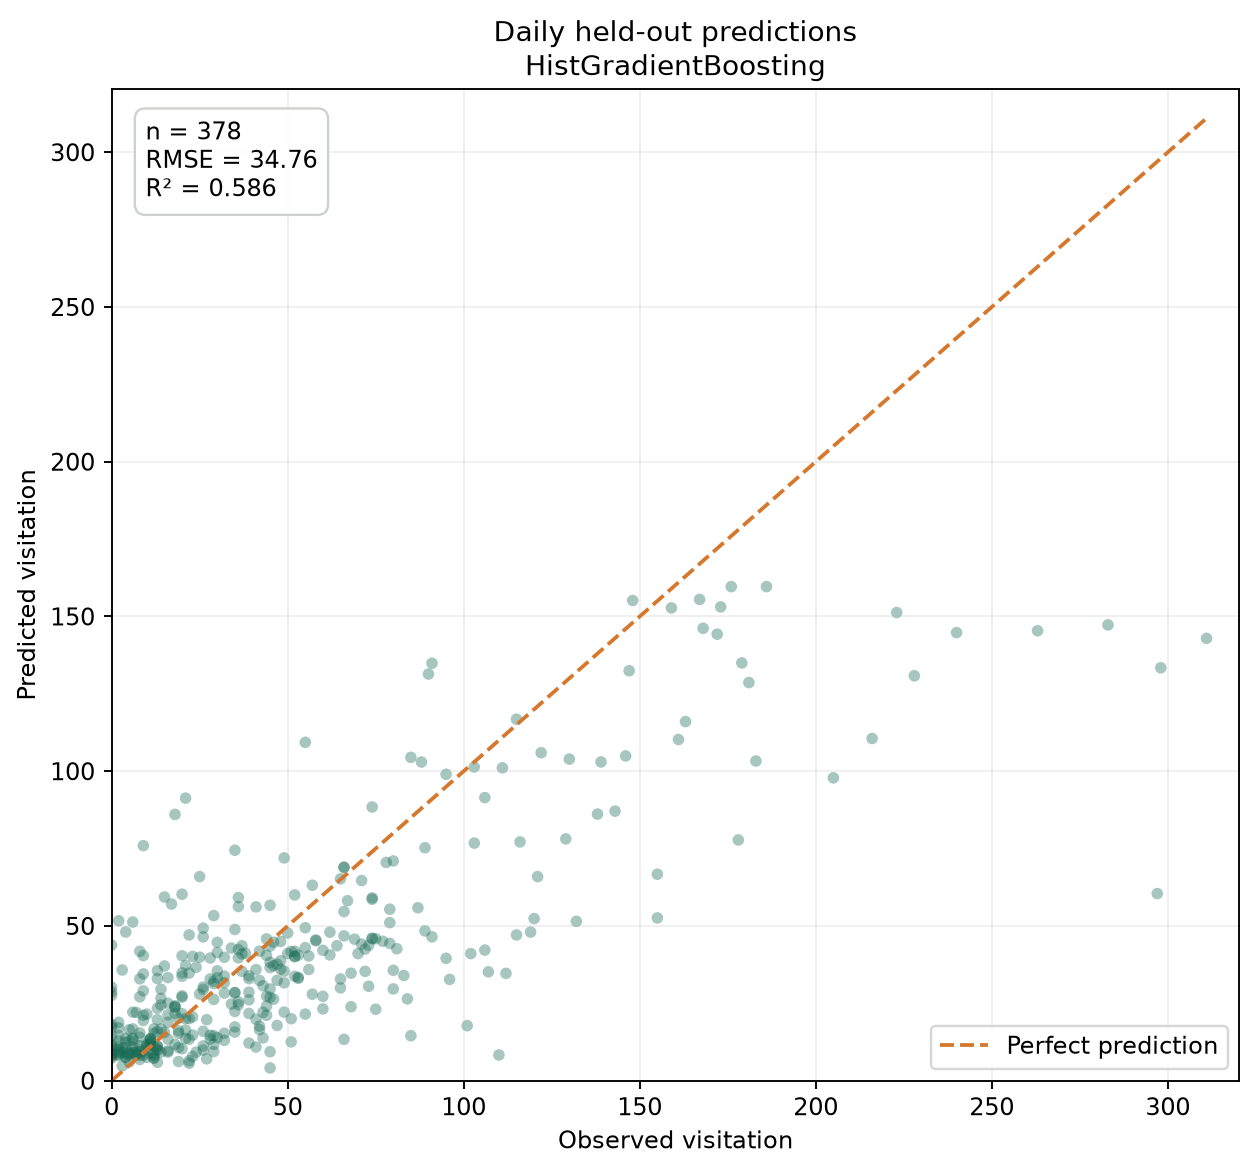

Observed-versus-predicted scatter: hourly


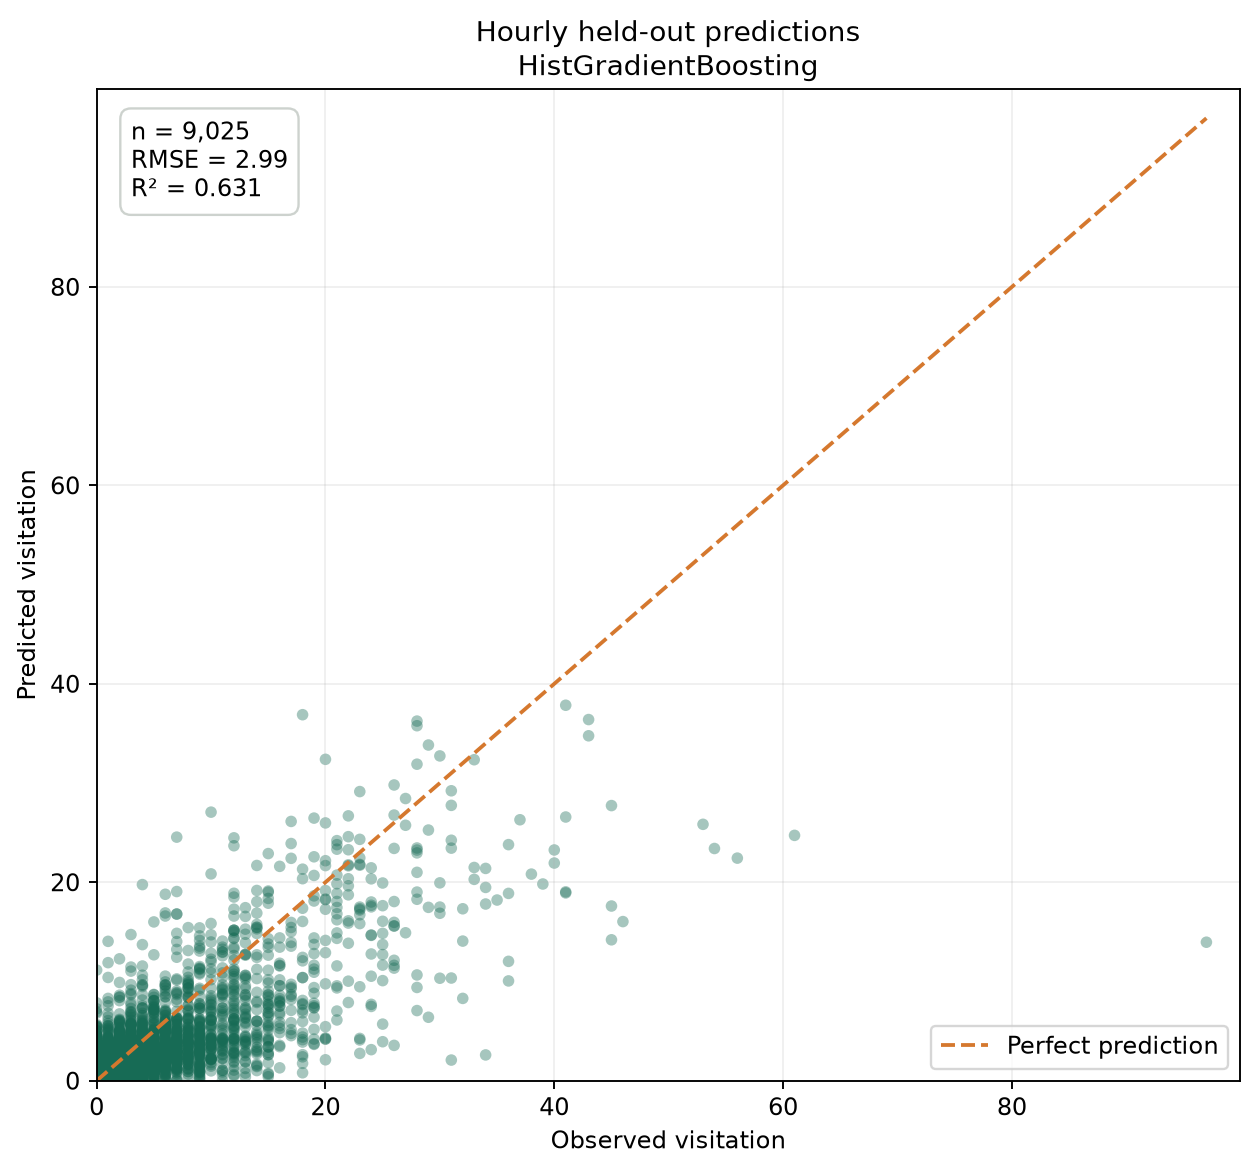

Observed-versus-predicted scatter: monthly


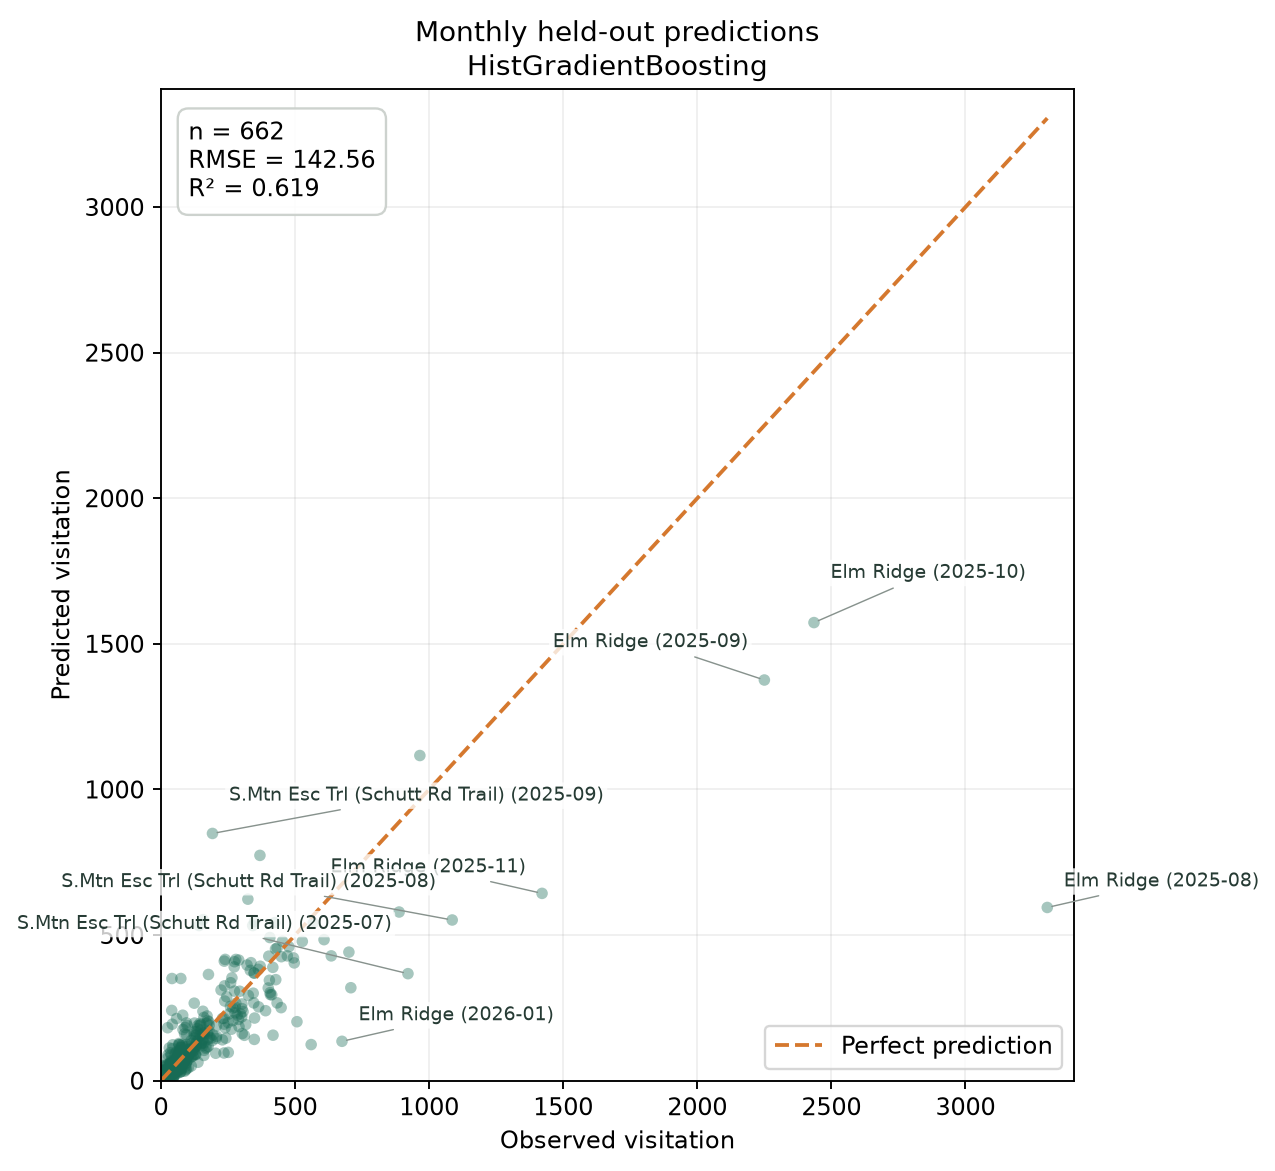

Observed-versus-predicted scatter: yearly


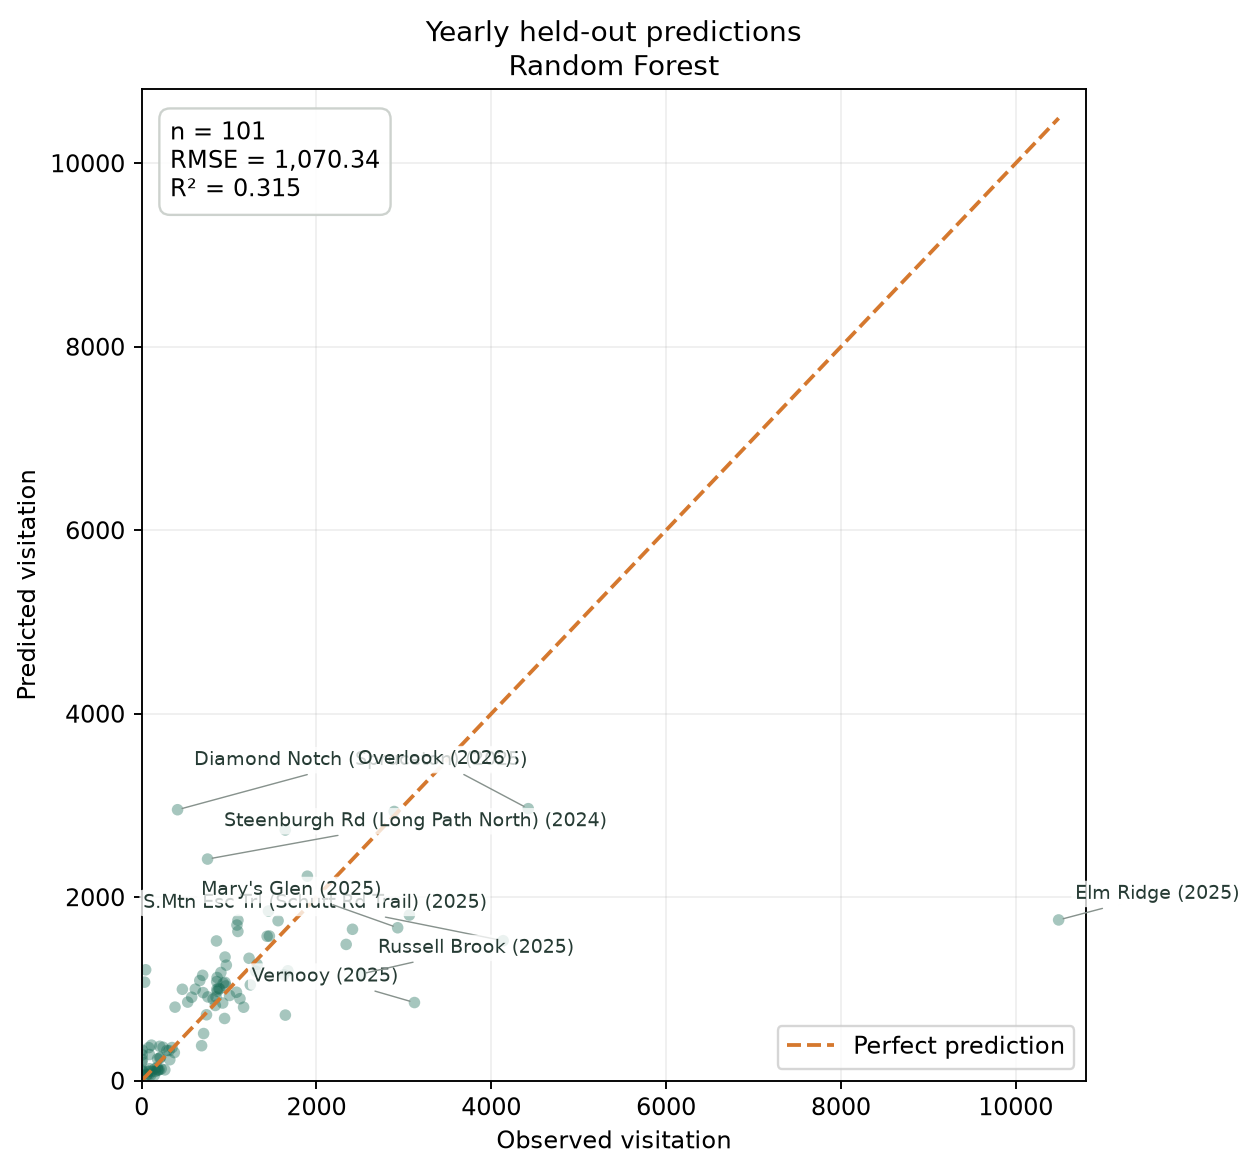

In [29]:
strava_result_rows=[]; strava_prediction_frames=[]; pca_coverage=[]
for frequency in CONFIG:
    print(f'\n=== {frequency.upper()} STRAVA-ENHANCED MODELING ===')
    data,history_features,location_features,weather_features,summary_features,pca_features,pca_variance=prepare_strava_model_data(frequency)
    train=data[data.split.eq('train')].copy(); test=data[data.split.eq('test')].copy()
    pca_coverage.append({'frequency':frequency,'pca_components':len(pca_features),'explained_variance_ratio':pca_variance,'train_rows':len(train),'test_rows':len(test),'locations':data.location.nunique(),'start':data.start_date.min(),'end':data.start_date.max()})
    same_window_baselines={'Previous observation':test['lag_1'].to_numpy(),'Seasonal naive':test[f"lag_{CONFIG[frequency]['seasonal_lag']}"].to_numpy()}
    for model_name,predicted in same_window_baselines.items():
        score=metrics(test.visitation_count,predicted)
        strava_result_rows.append({'frequency':frequency,'feature_set':'Baseline (same Strava window)','model':model_name,'train_rows':len(train),'test_rows':len(test),'locations':data.location.nunique(),'pca_components':0,'pca_explained_variance':np.nan,**score})
        frame=test[['location','start_date','visitation_count']].copy(); frame=frame.rename(columns={'visitation_count':'observed'}); frame['predicted']=predicted; frame['frequency']=frequency; frame['feature_set']='Baseline (same Strava window)'; frame['model']=model_name; strava_prediction_frames.append(frame)
    feature_sets={
        'History + calendar':history_features,
        'History + AllTrails location':history_features+location_features,
        'History + Strava summary + edge PCA + AllTrails location':history_features+summary_features+pca_features+location_features,
    }
    if weather_features:
        feature_sets['History + weather + AllTrails location']=history_features+location_features+weather_features
        feature_sets['History + Strava summary + edge PCA + AllTrails location + weather']=history_features+summary_features+pca_features+location_features+weather_features
    for feature_set,numeric_features in feature_sets.items():
        for model_name,model in sklearn_models(numeric_features).items():
            model.fit(train,np.log1p(train.visitation_count))
            predicted=np.maximum(0,np.expm1(model.predict(test)))
            score=metrics(test.visitation_count,predicted)
            strava_result_rows.append({'frequency':frequency,'feature_set':feature_set,'model':model_name,'train_rows':len(train),'test_rows':len(test),'locations':data.location.nunique(),'pca_components':len(pca_features) if 'PCA' in feature_set else 0,'pca_explained_variance':pca_variance if 'PCA' in feature_set else np.nan,**score})
            frame=test[['location','start_date','visitation_count']].copy(); frame=frame.rename(columns={'visitation_count':'observed'}); frame['predicted']=predicted; frame['frequency']=frequency; frame['feature_set']=feature_set; frame['model']=model_name
            strava_prediction_frames.append(frame)
            print(feature_set,'|',model_name,'| RMSE',round(score['RMSE'],3),'| R2',round(score['R2'],3))

strava_results=pd.DataFrame(strava_result_rows).sort_values(['frequency','RMSE']).reset_index(drop=True)
strava_predictions=pd.concat(strava_prediction_frames,ignore_index=True)
pca_coverage_df=pd.DataFrame(pca_coverage)
strava_results.to_csv(OUTPUT_DIR/'strava_enhanced_model_results.csv',index=False)
strava_predictions.to_csv(OUTPUT_DIR/'strava_enhanced_test_predictions.csv',index=False)
pca_coverage_df.to_csv(OUTPUT_DIR/'strava_pca_coverage.csv',index=False)

best_strava_models=(strava_results[strava_results.feature_set.str.startswith('History + Strava')].sort_values(['frequency','RMSE']).groupby('frequency',as_index=False).first())
baseline_best=(strava_results[strava_results.feature_set.str.startswith('Baseline')].sort_values(['frequency','RMSE']).groupby('frequency',as_index=False).first())
comparison=best_strava_models[['frequency','feature_set','model','RMSE','R2','MAE']].merge(baseline_best[['frequency','model','RMSE','R2']].rename(columns={'model':'same_window_baseline','RMSE':'baseline_RMSE','R2':'baseline_R2'}),on='frequency')
comparison['RMSE_improvement_pct']=100*(comparison.baseline_RMSE-comparison.RMSE)/comparison.baseline_RMSE
comparison.to_csv(OUTPUT_DIR/'strava_improvement_summary.csv',index=False)
print('\nBest Strava-aware result by frequency:'); display(comparison)
print('\nTraining-only PCA coverage:'); display(pca_coverage_df)

if HAS_MATPLOTLIB:
    for frequency,best in best_strava_models.set_index('frequency').iterrows():
        subset=strava_predictions[(strava_predictions.frequency==frequency)&(strava_predictions.feature_set==best.feature_set)&(strava_predictions.model==best.model)]
        location=subset.location.value_counts().index[0]; plot=subset[subset.location.eq(location)].sort_values('start_date').tail(500)
        fig,ax=plt.subplots(figsize=(13,5)); ax.plot(plot.start_date,plot.observed,label='Observed'); ax.plot(plot.start_date,plot.predicted,label='Predicted'); ax.set_title(f'{frequency.title()} best Strava-aware model: {location}'); ax.legend(); ax.grid(alpha=.25); fig.tight_layout(); fig.savefig(OUTPUT_DIR/f'{frequency}_best_strava_model.png',dpi=160,bbox_inches='tight'); plt.close(fig)
print('\nSaved Strava-enhanced outputs in',OUTPUT_DIR)

# Diagnostic scatter plots: observed visitation on x, predicted visitation on y.
# Each plot uses the best Strava-aware model for that frequency and only held-out test rows.
if HAS_MATPLOTLIB:
    from IPython.display import Image as NotebookImage, display as notebook_display
    for frequency,best in best_strava_models.set_index('frequency').iterrows():
        scatter_data=strava_predictions[
            (strava_predictions.frequency.eq(frequency)) &
            (strava_predictions.feature_set.eq(best.feature_set)) &
            (strava_predictions.model.eq(best.model))
        ][['location','start_date','observed','predicted']].replace([np.inf,-np.inf],np.nan).dropna(subset=['observed','predicted'])
        if scatter_data.empty:
            print(f'No valid held-out observations for {frequency}; scatter plot skipped.')
            continue
        axis_max=float(max(scatter_data.observed.max(),scatter_data.predicted.max(),1))
        fig,ax=plt.subplots(figsize=(7.5,7))
        ax.scatter(scatter_data.observed,scatter_data.predicted,s=24,alpha=.38,color='#176b55',edgecolors='none')
        ax.plot([0,axis_max],[0,axis_max],linestyle='--',linewidth=1.6,color='#d5782e',label='Perfect prediction')
        if frequency in {'monthly','yearly'}:
            # Label the eight held-out points with the largest absolute prediction errors.
            labeled_outliers=(scatter_data.assign(absolute_error=(scatter_data.predicted-scatter_data.observed).abs())
                              .nlargest(min(8,len(scatter_data)),'absolute_error'))
            for label_index,(_,point) in enumerate(labeled_outliers.iterrows()):
                period=pd.Timestamp(point.start_date).strftime('%Y-%m' if frequency=='monthly' else '%Y')
                offset_x=7 if label_index%2==0 else -7
                horizontal_alignment='left' if offset_x>0 else 'right'
                ax.annotate(f'{point.location} ({period})',(point.observed,point.predicted),xytext=(offset_x,7+(label_index%3)*5),textcoords='offset points',ha=horizontal_alignment,va='bottom',fontsize=8,color='#263b34',arrowprops={'arrowstyle':'-','color':'#87928d','linewidth':.6},bbox={'boxstyle':'round,pad=.2','facecolor':'white','edgecolor':'none','alpha':.78})
        ax.set_xlim(0,axis_max*1.03); ax.set_ylim(0,axis_max*1.03)
        ax.set_xlabel('Observed visitation'); ax.set_ylabel('Predicted visitation')
        ax.set_title(f'{frequency.title()} held-out predictions\n{best.model}')
        ax.text(.03,.97,f"n = {len(scatter_data):,}\nRMSE = {best.RMSE:,.2f}\nR² = {best.R2:.3f}",transform=ax.transAxes,va='top',ha='left',bbox={'boxstyle':'round,pad=.45','facecolor':'white','edgecolor':'#c8cec9','alpha':.9})
        ax.legend(loc='lower right'); ax.grid(alpha=.2); fig.tight_layout()
        scatter_path=OUTPUT_DIR/f'{frequency}_observed_vs_predicted_scatter.png'
        fig.savefig(scatter_path,dpi=170,bbox_inches='tight'); plt.close(fig)
        print(f'Observed-versus-predicted scatter: {frequency}')
        notebook_display(NotebookImage(filename=str(scatter_path)))

## Explicit Strava loading and location-specific edge discovery

This section visibly loads the existing Strava-derived monthly data. It uses the compact edge matrix already created from `State_model/monthly/strava_statewide_monthly.csv`, avoiding another multi-gigabyte copy. Change `SELECTED_LOCATION_FOR_EDGE_SEARCH`, rerun these cells, and inspect the relevant-edge table and location-specific model results.

Edge relevance is based only on chronological training months. Test months are excluded from edge ranking.

In [21]:
# ---------------- USER SELECTION ----------------
SELECTED_LOCATION_FOR_EDGE_SEARCH = 'Elm Ridge'  # Replace with any location printed below that has enough Strava overlap.
TOP_RELEVANT_EDGES = 25
MIN_EDGE_OVERLAP_MONTHS = 18
# ------------------------------------------------

RAW_STRAVA_MONTHLY_FILE = PROJECT_ROOT / 'State_model' / 'monthly' / 'strava_statewide_monthly.csv'
STRAVA_EDGE_MATRIX_FILE = PROJECT_ROOT / 'State_model' / 'global_model_outputs' / 'statewide_edge_month_matrix.csv'
STRAVA_NETWORK_FILE = PROJECT_ROOT / 'State_model' / 'global_model_outputs' / 'statewide_monthly_network_features.csv'
MONTHLY_VISITATION_FILE = DATA_DIR / 'monthly.csv'

print('Original monthly Strava source (not copied or rewritten):',RAW_STRAVA_MONTHLY_FILE)
print('Original source size, GB:',round(RAW_STRAVA_MONTHLY_FILE.stat().st_size/1e9,2))
print('Loading compact edge matrix:',STRAVA_EDGE_MATRIX_FILE)
strava_edges = pd.read_csv(STRAVA_EDGE_MATRIX_FILE)
strava_network = pd.read_csv(STRAVA_NETWORK_FILE)
strava_edges['start_date'] = pd.to_datetime(strava_edges.start_date).dt.to_period('M').dt.to_timestamp()
strava_network['start_date'] = pd.to_datetime(strava_network.start_date).dt.to_period('M').dt.to_timestamp()
strava_edge_columns = [c for c in strava_edges if c.startswith('edge_')]
print(f'Loaded {len(strava_edges):,} Strava months × {len(strava_edge_columns):,} candidate edges.')
print('Strava date range:',strava_edges.start_date.min(),'to',strava_edges.start_date.max())
display(strava_edges[['start_date']+strava_edge_columns[:8]].head())

monthly_visitation = pd.read_csv(MONTHLY_VISITATION_FILE)
monthly_visitation['start_date'] = pd.to_datetime(monthly_visitation.start_date).dt.to_period('M').dt.to_timestamp()
available_locations = sorted(monthly_visitation.location.dropna().unique())
print(f'Available monthly locations ({len(available_locations)}):')
print(available_locations)
if SELECTED_LOCATION_FOR_EDGE_SEARCH not in available_locations:
    raise ValueError(f'{SELECTED_LOCATION_FOR_EDGE_SEARCH!r} is unavailable. Copy an exact name from the list above.')

Original monthly Strava source (not copied or rewritten): /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/Final_CSC_Workspace/State_model/monthly/strava_statewide_monthly.csv
Original source size, GB: 5.2
Loading compact edge matrix: /Users/ineshvytheswaran/iCloud Drive (Archive)/Desktop/Desktop - MacBook Air (407)/CSC fellowship/Final_CSC_Workspace/State_model/global_model_outputs/statewide_edge_month_matrix.csv
Loaded 63 Strava months × 1,000 candidate edges.
Strava date range: 2021-01-01 00:00:00 to 2026-03-01 00:00:00


,start_date,edge_499382999,edge_499396166,edge_499396641,edge_499396648,edge_499396659,edge_499396684,edge_499396769,edge_499396797
0,2021-01-01,70.0,10.0,10.0,15.0,15.0,35.0,30.0,30.0
1,2021-02-01,60.0,5.0,5.0,5.0,5.0,10.0,25.0,25.0
2,2021-03-01,45.0,10.0,10.0,10.0,10.0,15.0,25.0,30.0
3,2021-04-01,40.0,40.0,30.0,30.0,30.0,30.0,30.0,30.0
4,2021-05-01,60.0,20.0,25.0,25.0,35.0,50.0,55.0,60.0


Available monthly locations (102):
['Acra Point', 'Alder Lake', 'All Canister Peaks', 'Ashokan HP', 'Balsam Cap', 'Balsam Lake Mountain', 'Bangle Hill', 'Barnum Road', 'Batavia Kill', 'Beaverkill Road to BLM FT', 'Becker Hollow', 'Beech Hill Rd', 'Big Indian', 'Big Pond East', 'Big Pond West', 'Biscuit Brook', 'Bouchoux Trail', 'Boulder Rock', 'Campbell Brook', 'Campbell Mt', 'Cathedral Glen', 'Catskill Mt. House', 'Colgate Lake (Dutcher Notch)', "Colonel's Chair", 'DRB Margaretville Pakatakan', 'Denning', 'Devils Tombstone (Hunter Mtn)', 'Devils Tombstone (Plateau Mtn)', 'Diamond Notch (Lanesville)', 'Diamond Notch (Spruceton)', 'Dry Brook Ridge to Lean-to', 'Eagle', 'East Windham', 'Elm Ridge', 'Fir', 'Flynn', 'Fox Hollow', 'Frick Pond', 'Friday', 'German Hollow', 'Giant Ledge', 'Halcott', 'Hardenburgh- MH Trail', 'Harding Road Trail', 'Hill Road (Huckleberry Loop N)', 'Holiday & Berry Brook Road', 'Huckleberry Loop Trail', 'Huggins Lake Trail', 'Kaaterskill Falls', 'Kaaterskill High

In [22]:
location_monthly = (monthly_visitation[monthly_visitation.location.eq(SELECTED_LOCATION_FOR_EDGE_SEARCH)]
                    [['location','start_date','visitation_count']].sort_values('start_date').drop_duplicates('start_date'))
edge_search_data = location_monthly.merge(strava_edges,on='start_date',how='inner').sort_values('start_date').reset_index(drop=True)
if len(edge_search_data) < MIN_EDGE_OVERLAP_MONTHS + 6:
    raise ValueError(f'Only {len(edge_search_data)} overlapping months are available; select a location with more Strava overlap or lower MIN_EDGE_OVERLAP_MONTHS carefully.')
n_test=max(1,int(np.ceil(len(edge_search_data)*0.20)))
edge_training=edge_search_data.iloc[:-n_test].copy(); edge_testing=edge_search_data.iloc[-n_test:].copy()
print(f'{SELECTED_LOCATION_FOR_EDGE_SEARCH}: {len(edge_search_data)} overlapping months; {len(edge_training)} training and {len(edge_testing)} untouched test months.')
print('Training:',edge_training.start_date.min(),'to',edge_training.start_date.max())
print('Testing:',edge_testing.start_date.min(),'to',edge_testing.start_date.max())

edge_relevance=[]
y=edge_training.visitation_count.astype(float)
for column in strava_edge_columns:
    x=pd.to_numeric(edge_training[column],errors='coerce')
    valid=x.gt(0)&y.notna()
    if valid.sum() < MIN_EDGE_OVERLAP_MONTHS or x[valid].nunique()<2: continue
    pearson=x[valid].corr(y[valid]); spearman=x[valid].corr(y[valid],method='spearman')
    if pd.notna(pearson): edge_relevance.append({'location':SELECTED_LOCATION_FOR_EDGE_SEARCH,'edge_uid':column.removeprefix('edge_'),'edge_column':column,'training_months':int(valid.sum()),'pearson_correlation':pearson,'spearman_correlation':spearman,'absolute_pearson':abs(pearson),'mean_monthly_trips':x[valid].mean(),'first_training_month':edge_training.loc[valid,'start_date'].min(),'last_training_month':edge_training.loc[valid,'start_date'].max()})
relevant_edges=pd.DataFrame(edge_relevance).sort_values(['absolute_pearson','training_months'],ascending=[False,False]).head(TOP_RELEVANT_EDGES).reset_index(drop=True)
if relevant_edges.empty: raise ValueError('No edges met the training-month coverage rule.')
print(f'Top {len(relevant_edges)} training-only edges relevant to {SELECTED_LOCATION_FOR_EDGE_SEARCH}:')
display(relevant_edges[['edge_uid','training_months','pearson_correlation','spearman_correlation','mean_monthly_trips','first_training_month','last_training_month']])
safe_location=''.join(ch.lower() if ch.isalnum() else '_' for ch in SELECTED_LOCATION_FOR_EDGE_SEARCH).strip('_')
relevant_edges.to_csv(OUTPUT_DIR/f'{safe_location}_relevant_strava_edges.csv',index=False)
if HAS_MATPLOTLIB:
    plot_edges=relevant_edges.head(15).sort_values('pearson_correlation')
    fig,ax=plt.subplots(figsize=(10,7)); colors=np.where(plot_edges.pearson_correlation>=0,'#2b8cbe','#d95f0e'); ax.barh(plot_edges.edge_uid.astype(str),plot_edges.pearson_correlation,color=colors); ax.axvline(0,color='black',linewidth=.8); ax.set_xlabel('Training-only Pearson correlation'); ax.set_title(f'Relevant Strava edges: {SELECTED_LOCATION_FOR_EDGE_SEARCH}'); fig.tight_layout(); fig.savefig(OUTPUT_DIR/f'{safe_location}_relevant_strava_edges.png',dpi=170,bbox_inches='tight'); plt.close(fig)

Elm Ridge: 63 overlapping months; 50 training and 13 untouched test months.
Training: 2021-01-01 00:00:00 to 2025-02-01 00:00:00
Testing: 2025-03-01 00:00:00 to 2026-03-01 00:00:00
Top 25 training-only edges relevant to Elm Ridge:


,edge_uid,training_months,pearson_correlation,spearman_correlation,mean_monthly_trips,first_training_month,last_training_month
0,511044745,50,0.923617,0.451504,1432.6,2021-01-01,2025-02-01
1,511050199,50,0.722867,-0.004254,160.0,2021-01-01,2025-02-01
2,510971725,50,0.720608,0.035699,743.6,2021-01-01,2025-02-01
3,510971726,50,0.720607,0.036269,692.9,2021-01-01,2025-02-01
4,510971730,50,0.714333,0.008912,565.2,2021-01-01,2025-02-01
5,510971731,50,0.712671,-0.021189,547.7,2021-01-01,2025-02-01
6,510971745,50,0.710253,0.022507,817.9,2021-01-01,2025-02-01
7,510971785,50,0.709405,0.038292,862.7,2021-01-01,2025-02-01
8,510971740,50,0.707819,0.084731,828.2,2021-01-01,2025-02-01
9,511052050,50,0.707426,0.187219,141.7,2021-01-01,2025-02-01


In [28]:
# Location-specific chronological modeling using the selected edges.
selected_edge_columns=relevant_edges.edge_column.tolist()
location_model=location_monthly.merge(strava_edges[['start_date']+selected_edge_columns],on='start_date',how='inner').merge(strava_network,on='start_date',how='left').sort_values('start_date').reset_index(drop=True)
location_model['lag_1']=location_model.visitation_count.shift(1)
location_model['lag_3']=location_model.visitation_count.shift(3)
location_model['lag_12']=location_model.visitation_count.shift(12)
location_model['rolling_3']=location_model.visitation_count.shift(1).rolling(3,min_periods=2).mean()
location_model['rolling_12']=location_model.visitation_count.shift(1).rolling(12,min_periods=4).mean()
location_model['month_sin']=np.sin(2*np.pi*location_model.start_date.dt.month/12)
location_model['month_cos']=np.cos(2*np.pi*location_model.start_date.dt.month/12)
location_model['trend']=np.arange(len(location_model))
history_cols=['lag_1','lag_3','lag_12','rolling_3','rolling_12','month_sin','month_cos','trend']
network_cols=[c for c in strava_network.columns if c.startswith('statewide_')]
location_model=location_model.dropna(subset=history_cols).reset_index(drop=True)
n_test=max(1,int(np.ceil(len(location_model)*0.20))); location_model['split']='train'; location_model.loc[location_model.index[-n_test:],'split']='test'
train=location_model[location_model.split.eq('train')]; test=location_model[location_model.split.eq('test')]

def location_algorithms(features):
    prep=Pipeline([('impute',SimpleImputer(strategy='median',add_indicator=True)),('scale',StandardScaler())])
    return {
        'Ridge':Pipeline([('preprocess',prep),('model',Ridge(alpha=10.0))]),
        'Random Forest':Pipeline([('preprocess',prep),('model',RandomForestRegressor(n_estimators=400,max_depth=8,min_samples_leaf=2,max_features=0.70,random_state=RANDOM_STATE,n_jobs=1))]),
        'HistGradientBoosting':Pipeline([('preprocess',prep),('model',HistGradientBoostingRegressor(learning_rate=.04,max_iter=500,max_leaf_nodes=12,min_samples_leaf=5,l2_regularization=3,early_stopping=True,random_state=RANDOM_STATE))])
    }

location_results=[]; location_predictions=[]
feature_sets={'History only':history_cols,'History + relevant Strava edges':history_cols+network_cols+selected_edge_columns}
baseline_pred=test.lag_12.fillna(test.lag_1).to_numpy(); baseline_score=metrics(test.visitation_count,baseline_pred)
location_results.append({'location':SELECTED_LOCATION_FOR_EDGE_SEARCH,'feature_set':'Baseline','model':'Seasonal naive',**baseline_score})
for feature_set,features in feature_sets.items():
    for model_name,model in location_algorithms(features).items():
        model.fit(train[features],np.log1p(train.visitation_count)); prediction=np.maximum(0,np.expm1(model.predict(test[features]))); score=metrics(test.visitation_count,prediction)
        location_results.append({'location':SELECTED_LOCATION_FOR_EDGE_SEARCH,'feature_set':feature_set,'model':model_name,**score})
        pred=test[['location','start_date','visitation_count']].copy().rename(columns={'visitation_count':'observed'}); pred['predicted']=prediction; pred['feature_set']=feature_set; pred['model']=model_name; location_predictions.append(pred)
location_results_df=pd.DataFrame(location_results).sort_values('RMSE').reset_index(drop=True)
location_predictions_df=pd.concat(location_predictions,ignore_index=True)
print('Location-specific model comparison:'); display(location_results_df)
location_results_df.to_csv(OUTPUT_DIR/f'{safe_location}_edge_model_results.csv',index=False)
location_predictions_df.to_csv(OUTPUT_DIR/f'{safe_location}_edge_model_predictions.csv',index=False)
print('Saved relevant-edge and model files for',SELECTED_LOCATION_FOR_EDGE_SEARCH)

Location-specific model comparison:


,location,feature_set,model,n,MAE,RMSE,R2,sMAPE_pct,bias
0,Elm Ridge,History only,HistGradientBoosting,11,439.487920,585.434930,0.682686,99.767483,-304.404330
1,Elm Ridge,Baseline,Seasonal naive,11,570.909091,798.608790,0.409527,97.380286,-85.636364
2,Elm Ridge,History only,Random Forest,11,754.187336,1138.761091,-0.200596,111.427883,-754.187336
3,Elm Ridge,History + relevant Strava edges,Random Forest,11,851.829122,1224.049406,-0.387170,105.888619,-797.205604
4,Elm Ridge,History + relevant Strava edges,HistGradientBoosting,11,950.508975,1304.925708,-0.576534,134.851101,-907.777873
5,Elm Ridge,History + relevant Strava edges,Ridge,11,97346.867718,216952.221631,-43576.269113,161.834890,96910.921187
6,Elm Ridge,History only,Ridge,11,167502.682520,386614.387851,-138383.621923,151.351617,167097.593415


Saved relevant-edge and model files for Elm Ridge


## Location counts and performance by location

This block reports the number of locations in every frequency file and calculates held-out performance separately for each location using the best overall approach for that frequency.

In [24]:
location_counts=[]
locations_by_frequency={}
for frequency,cfg in CONFIG.items():
    source=pd.read_csv(DATA_DIR/cfg['file'],usecols=['location'])
    locations=sorted(source.location.dropna().astype(str).str.strip().unique().tolist())
    locations_by_frequency[frequency]=locations
    location_counts.append({'frequency':frequency,'records':len(source),'total_locations':source.location.nunique()})
location_counts_df=pd.DataFrame(location_counts)
print('Locations available by frequency:')
display(location_counts_df)
for frequency,locations in locations_by_frequency.items():
    print(f'\n{frequency.upper()} LOCATIONS ({len(locations)}):')
    for location in locations:
        print('-',location)
all_available_locations=sorted(set().union(*locations_by_frequency.values()))
print(f'\nALL UNIQUE LOCATIONS ACROSS FREQUENCIES ({len(all_available_locations)}):')
for location in all_available_locations:
    print('-',location)

all_model_results=pd.read_csv(OUTPUT_DIR/'strava_enhanced_model_results.csv')
all_test_predictions=pd.read_csv(OUTPUT_DIR/'strava_enhanced_test_predictions.csv')
all_test_predictions['start_date']=pd.to_datetime(all_test_predictions.start_date)
best_overall=(all_model_results.sort_values(['frequency','RMSE']).groupby('frequency',as_index=False).first())
performance_rows=[]
for _,best in best_overall.iterrows():
    chosen=all_test_predictions[(all_test_predictions.frequency.eq(best.frequency))&(all_test_predictions.feature_set.eq(best.feature_set))&(all_test_predictions.model.eq(best.model))]
    for location,g in chosen.groupby('location'):
        score=metrics(g.observed,g.predicted)
        performance_rows.append({'frequency':best.frequency,'location':location,'feature_set':best.feature_set,'model':best.model,'test_start':g.start_date.min(),'test_end':g.start_date.max(),**score})
per_location_performance=pd.DataFrame(performance_rows).sort_values(['frequency','RMSE']).reset_index(drop=True)
print(f'Performance calculated for {per_location_performance.location.nunique():,} unique locations across {len(per_location_performance):,} frequency-location combinations.')
print('Best overall approach used for each frequency:')
display(best_overall[['frequency','feature_set','model','test_rows','locations','MAE','RMSE','R2']])
print('Held-out performance by location:')
display(per_location_performance)
per_location_performance.to_csv(OUTPUT_DIR/'per_location_performance.csv',index=False)

Locations available by frequency:


,frequency,records,total_locations
0,hourly,49033,1
1,daily,2051,1
2,monthly,21240,102
3,yearly,2148,102



HOURLY LOCATIONS (1):
- Elm Ridge

DAILY LOCATIONS (1):
- Elm Ridge

MONTHLY LOCATIONS (102):
- Acra Point
- Alder Lake
- All Canister Peaks
- Ashokan HP
- Balsam Cap
- Balsam Lake Mountain
- Bangle Hill
- Barnum Road
- Batavia Kill
- Beaverkill Road to BLM FT
- Becker Hollow
- Beech Hill Rd
- Big Indian
- Big Pond East
- Big Pond West
- Biscuit Brook
- Bouchoux Trail
- Boulder Rock
- Campbell Brook
- Campbell Mt
- Cathedral Glen
- Catskill Mt. House
- Colgate Lake (Dutcher Notch)
- Colonel's Chair
- DRB Margaretville Pakatakan
- Denning
- Devils Tombstone (Hunter Mtn)
- Devils Tombstone (Plateau Mtn)
- Diamond Notch (Lanesville)
- Diamond Notch (Spruceton)
- Dry Brook Ridge to Lean-to
- Eagle
- East Windham
- Elm Ridge
- Fir
- Flynn
- Fox Hollow
- Frick Pond
- Friday
- German Hollow
- Giant Ledge
- Halcott
- Hardenburgh- MH Trail
- Harding Road Trail
- Hill Road (Huckleberry Loop N)
- Holiday & Berry Brook Road
- Huckleberry Loop Trail
- Huggins Lake Trail
- Kaaterskill Falls
- Kaate

,frequency,feature_set,model,test_rows,locations,MAE,RMSE,R2
0,daily,History + Strava summary + edge PCA,HistGradientBoosting,378,1,21.883451,34.755398,0.585516
1,hourly,History + Strava summary + edge PCA,HistGradientBoosting,9025,1,1.251496,2.989553,0.631251
2,monthly,Baseline (same Strava window),Seasonal naive,662,79,46.834588,137.226326,0.647276
3,yearly,History + Strava summary + edge PCA,Random Forest,101,90,444.799819,1070.341820,0.315242


Held-out performance by location:


,frequency,location,feature_set,model,test_start,test_end,n,MAE,RMSE,R2,sMAPE_pct,bias
0,daily,Elm Ridge,History + Strava summary + edge PCA,HistGradientBoosting,2025-03-15 00:00:00,2026-03-31 00:00:00,378,21.883451,34.755398,0.585516,58.853324,-10.346926
1,hourly,Elm Ridge,History + Strava summary + edge PCA,HistGradientBoosting,2025-03-14 09:00:00,2026-03-31 23:00:00,9025,1.251496,2.989553,0.631251,142.806265,-0.485556
2,monthly,Bangle Hill,Baseline (same Strava window),Seasonal naive,2025-06-01 00:00:00,2026-03-01 00:00:00,10,0.000000,0.000000,1.000000,0.000000,0.000000
3,monthly,Cathedral Glen,Baseline (same Strava window),Seasonal naive,2025-11-01 00:00:00,2026-03-01 00:00:00,5,0.000000,0.000000,1.000000,0.000000,0.000000
4,monthly,Trails End Road,Baseline (same Strava window),Seasonal naive,2025-07-01 00:00:00,2026-03-01 00:00:00,9,0.000000,0.000000,1.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
166,yearly,Vernooy,History + Strava summary + edge PCA,Random Forest,2025-01-01 00:00:00,2026-01-01 00:00:00,2,1371.351866,1639.277310,-3.819187,74.135187,-1371.351866
167,yearly,Steenburgh Rd (Long Path North),History + Strava summary + edge PCA,Random Forest,2024-01-01 00:00:00,2024-01-01 00:00:00,1,1661.581354,1661.581354,NaN,104.845478,1661.581354
168,yearly,Diamond Notch (Spruceton),History + Strava summary + edge PCA,Random Forest,2025-01-01 00:00:00,2025-01-01 00:00:00,1,2542.414344,2542.414344,NaN,151.135626,2542.414344
169,yearly,S.Mtn Esc Trl (Schutt Rd Trail),History + Strava summary + edge PCA,Random Forest,2025-01-01 00:00:00,2025-01-01 00:00:00,1,2610.544697,2610.544697,NaN,92.221684,-2610.544697


## Choose a location: visitation forecast and relevant-edge heat map

Edit `GRAPH_LOCATION` and `GRAPH_FREQUENCY`, then rerun this block. Graph 1 compares held-out visitation with the selected frequency's best estimate. Graph 2 displays standardized monthly activity for the strongest training-only Strava edges associated with that location.

Locations with held-out monthly predictions (79):
['Acra Point', 'Alder Lake', 'Ashokan HP', 'Bangle Hill', 'Barnum Road', 'Batavia Kill', 'Beaverkill Road to BLM FT', 'Becker Hollow', 'Beech Hill Rd', 'Big Pond East', 'Big Pond West', 'Biscuit Brook', 'Bouchoux Trail', 'Campbell Brook', 'Campbell Mt', 'Cathedral Glen', 'Catskill Mt. House', 'Colgate Lake (Dutcher Notch)', "Colonel's Chair", 'DRB Margaretville Pakatakan', 'Denning', 'Devils Tombstone (Hunter Mtn)', 'Devils Tombstone (Plateau Mtn)', 'Diamond Notch (Lanesville)', 'Diamond Notch (Spruceton)', 'Dry Brook Ridge to Lean-to', 'East Windham', 'Elm Ridge', 'Flynn', 'Fox Hollow', 'Frick Pond', 'German Hollow', 'Giant Ledge', 'Hardenburgh- MH Trail', 'Harding Road Trail', 'Hill Road (Huckleberry Loop N)', 'Holiday & Berry Brook Road', 'Huckleberry Loop Trail', 'Huggins Lake Trail', 'Kelly Hollow', 'Lane Street', 'Little Pond Campground', 'Little Pond Loop', 'Long Path North', 'Long Pond', 'Mary Smith Hill Road', "Mary's Glen", 'M

,start_date,observed,predicted
76132,2025-03-01,31.0,100.0
76133,2025-04-01,43.0,135.0
76134,2025-05-01,97.0,164.0
76135,2025-06-01,145.0,97.0
76136,2025-07-01,142.0,2177.0
76137,2025-08-01,3305.0,2163.0
76138,2025-09-01,2250.0,2168.0
76139,2025-10-01,2435.0,2695.0
76140,2025-11-01,1421.0,1728.0
76141,2025-12-01,560.0,18.0


Observed-versus-estimated graph:


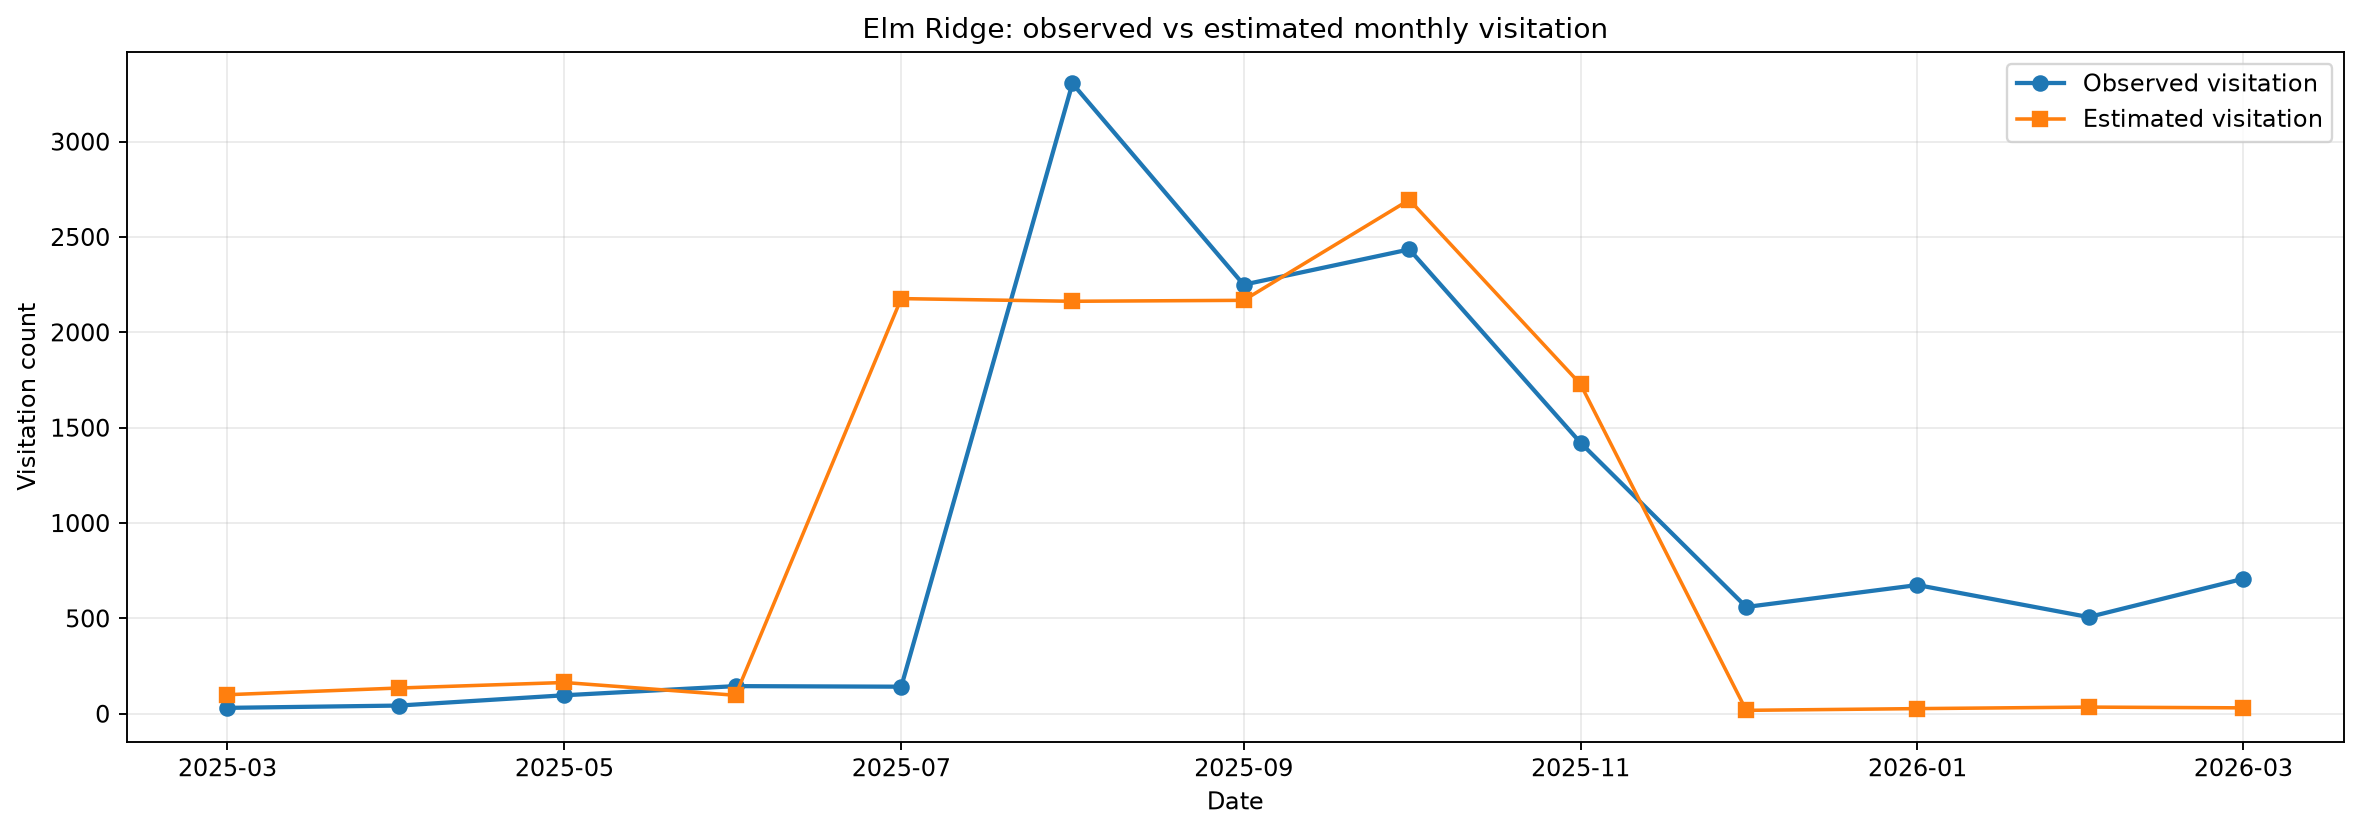

The compact PCA matrix had no local edges, so the existing raw monthly file was streamed without creating a copy.
Local map network: 909 geometries; 359 edges with monthly activity.
Geographic Strava-edge heat map:


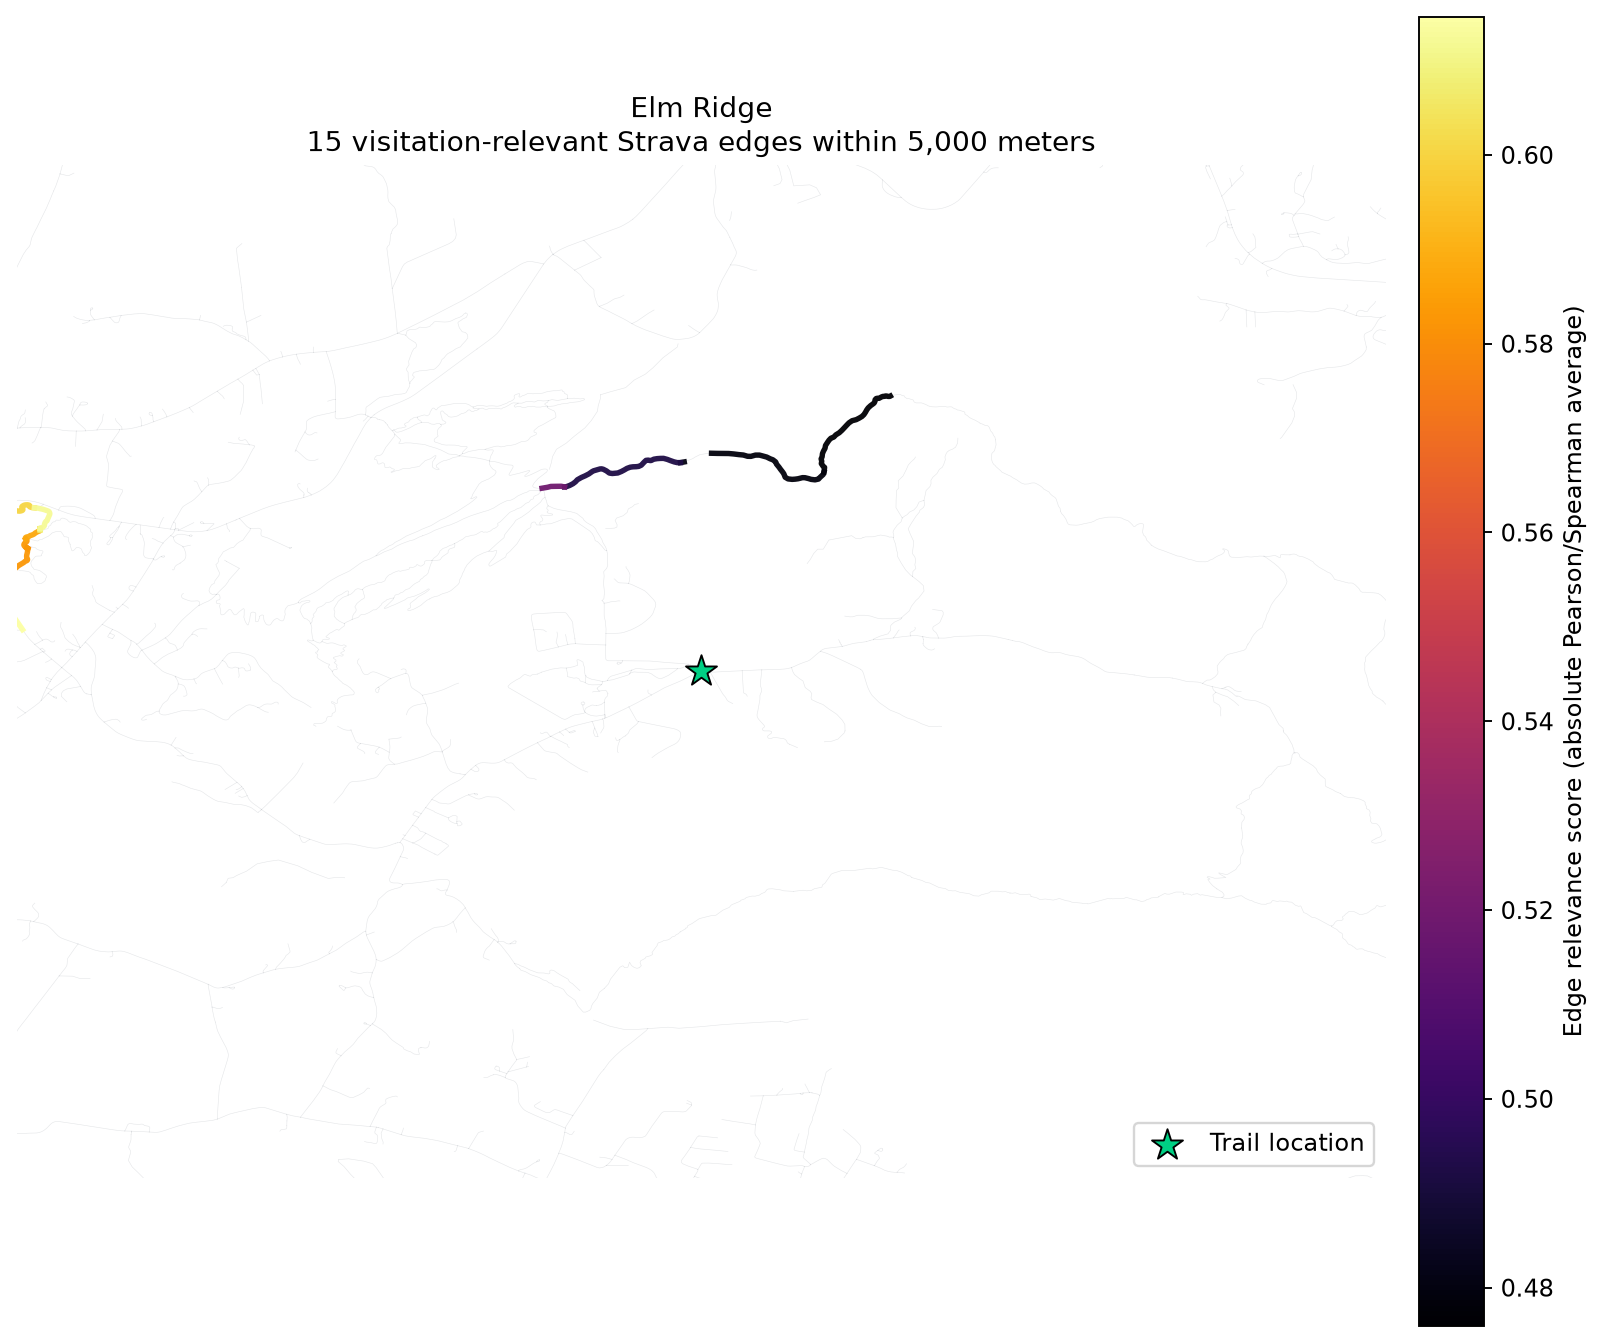

,edge_uid,training_months,pearson,spearman,relevance_score
6,514762148,13,0.613767,0.615457,0.614612
14,514762310,44,0.666712,0.557565,0.612138
12,514762308,46,0.676680,0.541157,0.608919
13,514762309,45,0.675576,0.533163,0.604370
15,514762311,43,0.672177,0.528704,0.600440
11,514762298,46,0.655134,0.520499,0.587816
8,514762294,46,0.645405,0.521285,0.583345
7,514762290,46,0.661324,0.504128,0.582726
10,514762296,46,0.643353,0.518187,0.580770
9,514762295,46,0.642999,0.507584,0.575292


In [26]:
# ---------------- USER GRAPH SELECTION ----------------
GRAPH_LOCATION = 'Elm Ridge'
GRAPH_FREQUENCY = 'monthly'  # hourly, daily, monthly, or yearly
HEATMAP_EDGE_COUNT = 15
MAP_RADIUS_METERS = 5000  # Local Strava network shown around the selected trail.
# ------------------------------------------------------
try:
    from IPython.display import Image as NotebookImage, display as notebook_display
except ImportError:
    NotebookImage=None; notebook_display=None

def display_saved_graph(path):
    path=Path(path)
    if not path.exists(): raise FileNotFoundError(path)
    if NotebookImage is not None:
        notebook_display(NotebookImage(filename=str(path)))
    else:
        print('Graph saved at:',path)

available_graph_locations=sorted(per_location_performance.loc[per_location_performance.frequency.eq(GRAPH_FREQUENCY),'location'].unique())
print(f'Locations with held-out {GRAPH_FREQUENCY} predictions ({len(available_graph_locations)}):')
print(available_graph_locations)
if GRAPH_LOCATION not in available_graph_locations:
    raise ValueError(f'{GRAPH_LOCATION!r} has no held-out {GRAPH_FREQUENCY} predictions. Choose an exact location printed above.')

best=best_overall[best_overall.frequency.eq(GRAPH_FREQUENCY)].iloc[0]
graph_predictions=all_test_predictions[(all_test_predictions.frequency.eq(GRAPH_FREQUENCY))&(all_test_predictions.location.eq(GRAPH_LOCATION))&(all_test_predictions.feature_set.eq(best.feature_set))&(all_test_predictions.model.eq(best.model))].sort_values('start_date')
graph_score=metrics(graph_predictions.observed,graph_predictions.predicted)
print('Selected model:',best.feature_set,'|',best.model)
print('Location performance:',graph_score)
display(graph_predictions[['start_date','observed','predicted']])

fig,ax=plt.subplots(figsize=(14,5))
ax.plot(graph_predictions.start_date,graph_predictions.observed,marker='o',label='Observed visitation',linewidth=1.8)
ax.plot(graph_predictions.start_date,graph_predictions.predicted,marker='s',label='Estimated visitation',linewidth=1.5)
ax.set_title(f'{GRAPH_LOCATION}: observed vs estimated {GRAPH_FREQUENCY} visitation')
ax.set_xlabel('Date'); ax.set_ylabel('Visitation count'); ax.legend(); ax.grid(alpha=.25); fig.tight_layout()
graph_safe=''.join(ch.lower() if ch.isalnum() else '_' for ch in GRAPH_LOCATION).strip('_')
visitation_graph_path=OUTPUT_DIR/f'{graph_safe}_{GRAPH_FREQUENCY}_visitation_vs_estimate.png'
fig.savefig(visitation_graph_path,dpi=170,bbox_inches='tight')
plt.close(fig)
print('Observed-versus-estimated graph:')
display_saved_graph(visitation_graph_path)

# Recalculate relevant edges for the selected location using training months only.
monthly_for_heatmap=pd.read_csv(DATA_DIR/'monthly.csv',usecols=['location','start_date','visitation_count'])
monthly_for_heatmap['start_date']=pd.to_datetime(monthly_for_heatmap.start_date).dt.to_period('M').dt.to_timestamp()
vis=monthly_for_heatmap[monthly_for_heatmap.location.eq(GRAPH_LOCATION)].sort_values('start_date').drop_duplicates('start_date')
# Resolve a trail center, then limit edge selection to the local network as in State_model.
import json, shapefile
from matplotlib.colors import Normalize
coordinate_file=PROJECT_ROOT/'State_model'/'global_model_outputs'/'trail_weather'/'trail_coordinates.csv'
trail_coordinates=pd.read_csv(coordinate_file) if coordinate_file.exists() else pd.DataFrame()
# Elm Ridge is absent from the saved geocoder table; this is its Peck Road trailhead.
coordinate_overrides={'Elm Ridge':(42.29033,-74.16054)}
if GRAPH_LOCATION in coordinate_overrides:
    trail_latitude,trail_longitude=coordinate_overrides[GRAPH_LOCATION]
else:
    coordinate_match=trail_coordinates[trail_coordinates.location.eq(GRAPH_LOCATION)]
    if coordinate_match.empty:
        raise ValueError(f'No map coordinates are available for {GRAPH_LOCATION!r}. Add it to coordinate_overrides as (latitude, longitude).')
    trail_latitude=float(coordinate_match.iloc[0].latitude); trail_longitude=float(coordinate_match.iloc[0].longitude)

shape_files=sorted((PROJECT_ROOT/'State_model'/'daily').glob('*/*.shp'))
if not shape_files: raise FileNotFoundError('No Strava edge shapefiles were found under State_model/daily.')
latitude_radius=MAP_RADIUS_METERS/111_320
longitude_radius=MAP_RADIUS_METERS/(111_320*np.cos(np.deg2rad(trail_latitude)))
map_bounds=(trail_longitude-longitude_radius,trail_latitude-latitude_radius,trail_longitude+longitude_radius,trail_latitude+latitude_radius)
reader=shapefile.Reader(str(shape_files[0]))
local_edge_shapes={int(item.record[0]):item.shape for item in reader.iterShapeRecords(fields=['edgeUID'],bbox=map_bounds)}
local_edge_columns=[f'edge_{uid}' for uid in local_edge_shapes if f'edge_{uid}' in strava_edge_columns]
if local_edge_columns:
    local_strava_monthly=strava_edges[['start_date']+local_edge_columns].copy()
else:
    # The compact PCA matrix may not contain this trail's local edges. In that case,
    # stream the existing large monthly CSV and keep only local IDs in memory.
    raw_local_parts=[]; local_ids=set(local_edge_shapes)
    for chunk in pd.read_csv(RAW_STRAVA_MONTHLY_FILE,usecols=['edge_uid','start_date','total_trip_count'],chunksize=500_000):
        chunk['edge_uid']=pd.to_numeric(chunk.edge_uid,errors='coerce')
        matched=chunk[chunk.edge_uid.isin(local_ids)].copy()
        if not matched.empty: raw_local_parts.append(matched)
    if not raw_local_parts: raise ValueError(f'No monthly Strava records were found within {MAP_RADIUS_METERS:,} meters of {GRAPH_LOCATION}.')
    local_long=pd.concat(raw_local_parts,ignore_index=True)
    local_long['start_date']=pd.to_datetime(local_long.start_date).dt.to_period('M').dt.to_timestamp()
    local_long['edge_column']='edge_'+local_long.edge_uid.astype('int64').astype(str)
    local_strava_monthly=(local_long.groupby(['start_date','edge_column'],as_index=False).total_trip_count.sum()
                          .pivot(index='start_date',columns='edge_column',values='total_trip_count').fillna(0).reset_index())
    local_strava_monthly.columns.name=None
    local_edge_columns=[column for column in local_strava_monthly if column.startswith('edge_')]
    print('The compact PCA matrix had no local edges, so the existing raw monthly file was streamed without creating a copy.')
print(f'Local map network: {len(local_edge_shapes):,} geometries; {len(local_edge_columns):,} edges with monthly activity.')
edge_data=vis.merge(local_strava_monthly,on='start_date',how='inner').sort_values('start_date').reset_index(drop=True)
if len(edge_data)<18: raise ValueError(f'{GRAPH_LOCATION} has only {len(edge_data)} overlapping monthly Strava observations; at least 18 are required for the heat map.')
heatmap_test=max(1,int(np.ceil(len(edge_data)*.20))); heatmap_train=edge_data.iloc[:-heatmap_test]

# Rank only local edges and use training months only to avoid test leakage.
edge_scores=[]
for edge in local_edge_columns:
    x=pd.to_numeric(heatmap_train[edge],errors='coerce'); valid=x.gt(0)&heatmap_train.visitation_count.notna()
    if valid.sum()<12 or x[valid].nunique()<2: continue
    pearson=x[valid].corr(heatmap_train.loc[valid,'visitation_count']); spearman=x[valid].corr(heatmap_train.loc[valid,'visitation_count'],method='spearman')
    if pd.notna(pearson): edge_scores.append({'edge':edge,'edge_uid':int(edge.removeprefix('edge_')),'pearson':pearson,'spearman':spearman,'relevance_score':(abs(pearson)+abs(spearman))/2,'training_months':int(valid.sum())})
if not edge_scores: raise ValueError(f'No local edges for {GRAPH_LOCATION} met the minimum training-data requirement.')
heatmap_edges=pd.DataFrame(edge_scores).sort_values(['relevance_score','training_months'],ascending=False).head(HEATMAP_EDGE_COUNT)
selected_edge_ids=set(heatmap_edges.edge_uid.astype(int))
mapped_edges=heatmap_edges.copy()
score_min=float(mapped_edges.relevance_score.min()); score_max=float(mapped_edges.relevance_score.max())
if score_min==score_max: score_max=score_min+1e-9
normalizer=Normalize(vmin=score_min,vmax=score_max)
color_map=plt.get_cmap('inferno')
fig,ax=plt.subplots(figsize=(10,8))
# Draw the complete local network faintly for geographic context.
for shape in local_edge_shapes.values():
    parts=list(shape.parts)+[len(shape.points)]
    for part_start,part_end in zip(parts[:-1],parts[1:]):
        coordinates=np.asarray(shape.points[part_start:part_end],dtype=float)
        if len(coordinates): ax.plot(coordinates[:,0],coordinates[:,1],color='#6f7782',linewidth=.25,alpha=.18,zorder=1)
# Highlight locally selected edges, colored by their visitation relevance.
for _,edge_row in mapped_edges.sort_values('relevance_score').iterrows():
    edge_uid=int(edge_row.edge_uid); shape=local_edge_shapes[edge_uid]
    color=color_map(normalizer(edge_row.relevance_score))
    parts=list(shape.parts)+[len(shape.points)]
    for part_start,part_end in zip(parts[:-1],parts[1:]):
        coordinates=np.asarray(shape.points[part_start:part_end],dtype=float)
        if len(coordinates): ax.plot(coordinates[:,0],coordinates[:,1],color=color,linewidth=2.3,alpha=.95,zorder=3)
# Draw a verified trail line when one is available. Do not plot a point inferred
# from a manually supplied trailhead coordinate.
trail_files={'Ashokan HP':'Ashokan_High_Point_Trail.js','Vernooy':'Vernooy_Falls_Trail.js'}
trail_file=PROJECT_ROOT/'State_model'/'trails'/trail_files.get(GRAPH_LOCATION,'')
trail_line_drawn=False
if trail_file.is_file():
    trail_geojson=json.loads(trail_file.read_text())
    for feature in trail_geojson.get('features',[]):
        geometry=feature.get('geometry',{}); coordinate_groups=geometry.get('coordinates',[])
        if geometry.get('type')=='LineString': coordinate_groups=[coordinate_groups]
        for group in coordinate_groups:
            trail_xy=np.asarray([[point[0],point[1]] for point in group],dtype=float)
            ax.plot(trail_xy[:,0],trail_xy[:,1],color='#00d084',linewidth=3.0,zorder=4,label='Trail geometry')
            trail_line_drawn=True
ax.set_xlim(map_bounds[0],map_bounds[2]); ax.set_ylim(map_bounds[1],map_bounds[3])
ax.set_aspect('equal',adjustable='box')
ax.set_title(f'{GRAPH_LOCATION}\n{len(selected_edge_ids):,} visitation-relevant Strava edges within {MAP_RADIUS_METERS:,} meters')
ax.set_axis_off()
colorbar=fig.colorbar(plt.cm.ScalarMappable(norm=normalizer,cmap=color_map),ax=ax,pad=.02)
colorbar.set_label('Edge relevance score (absolute Pearson/Spearman average)')
if trail_line_drawn: ax.legend(loc='lower right')
fig.tight_layout()
edge_heatmap_path=OUTPUT_DIR/f'{graph_safe}_relevant_edges_geographic_heatmap.png'
fig.savefig(edge_heatmap_path,dpi=170,bbox_inches='tight')
plt.close(fig)
print('Geographic Strava-edge heat map:')
display_saved_graph(edge_heatmap_path)
display(heatmap_edges[['edge_uid','training_months','pearson','spearman','relevance_score']])